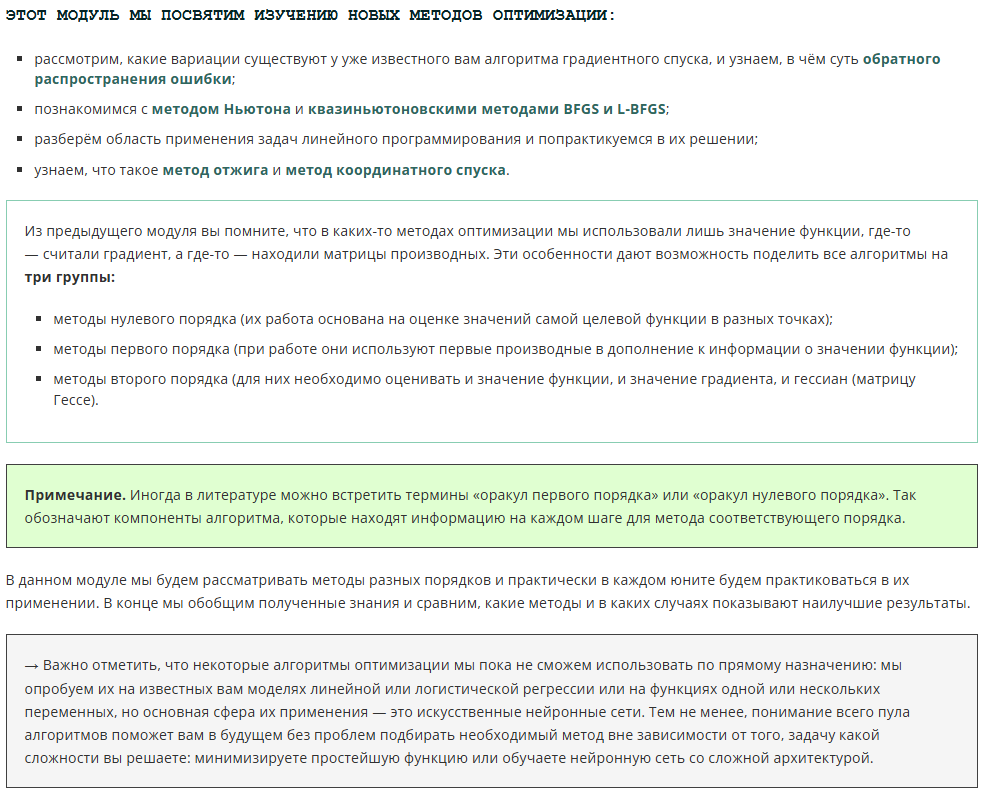

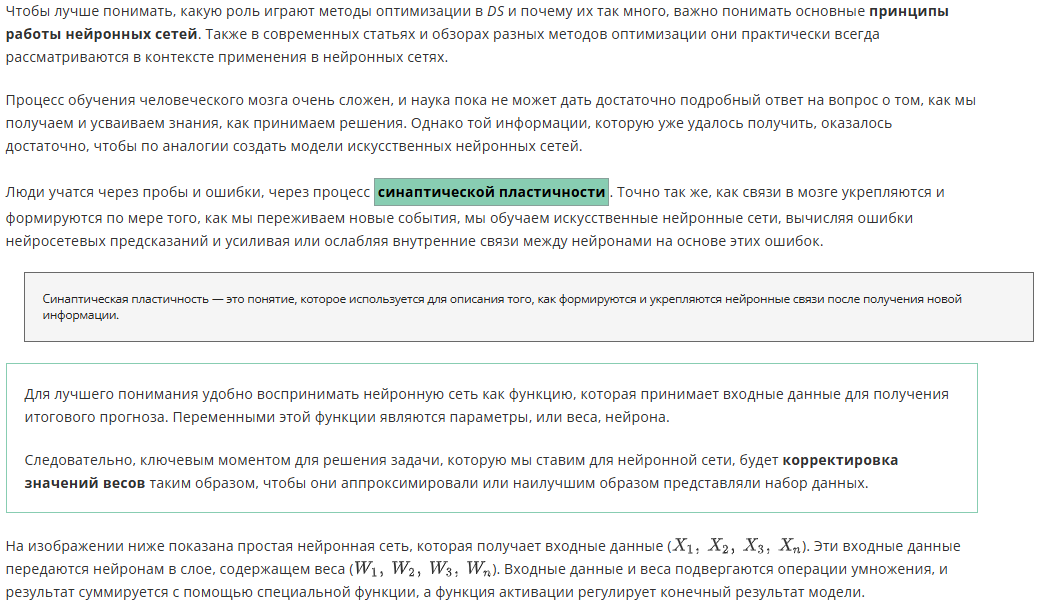

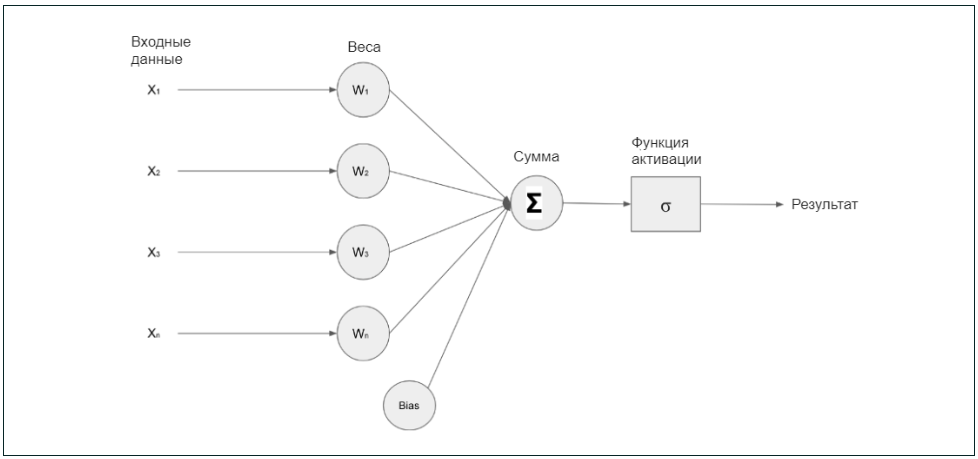

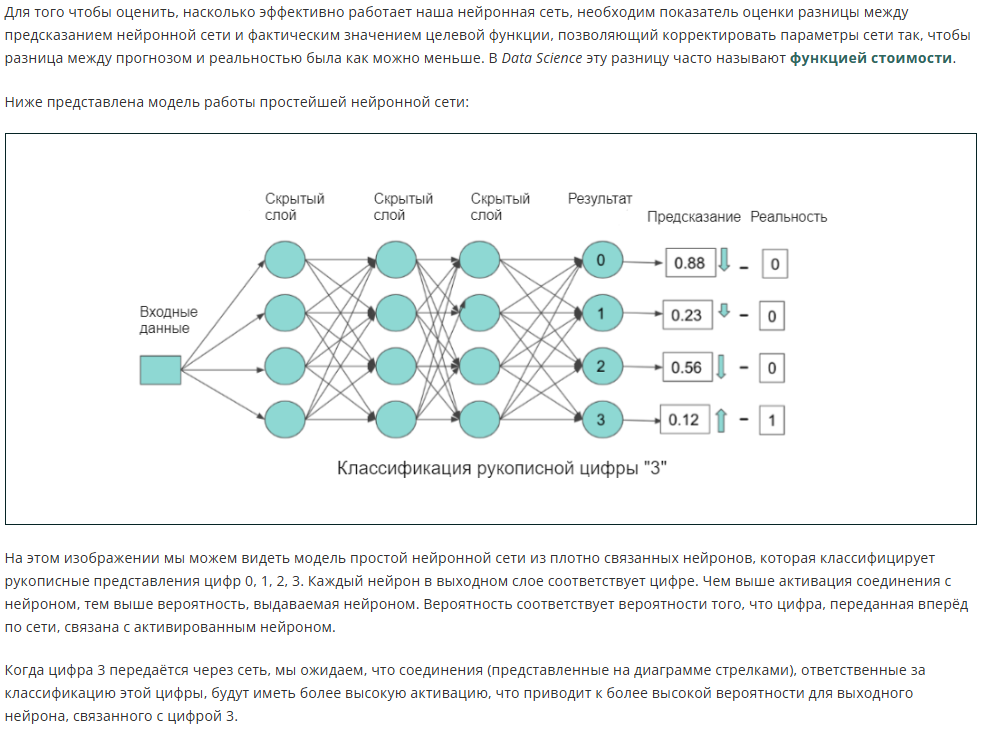

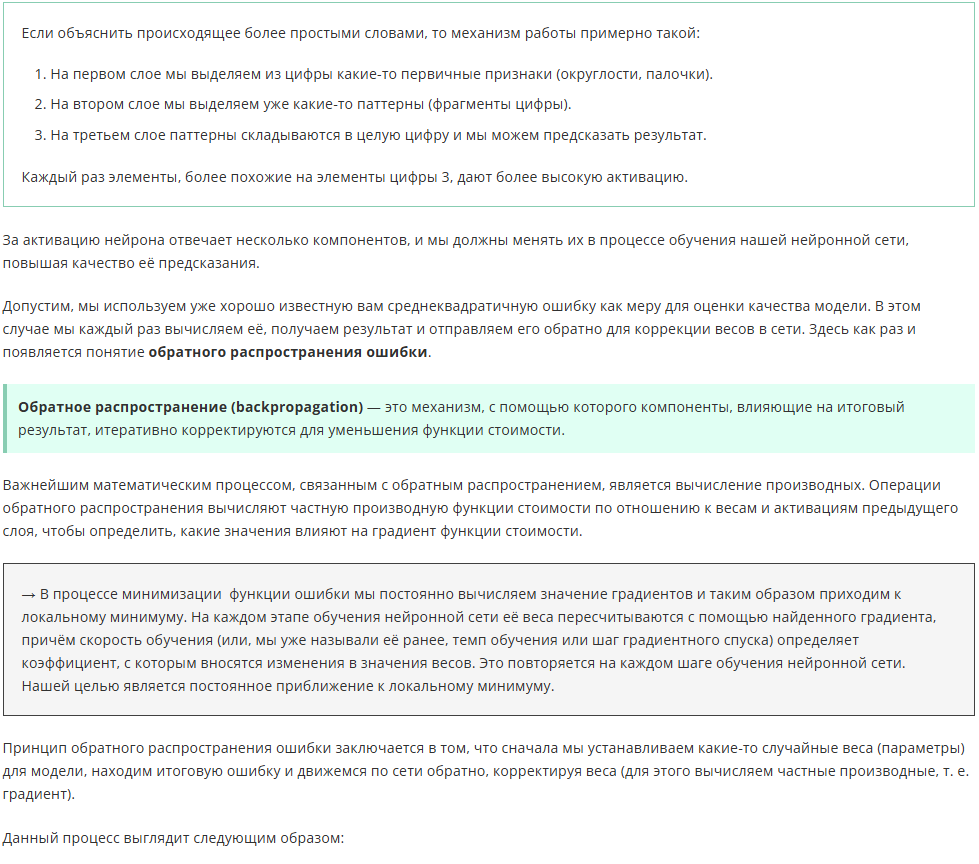

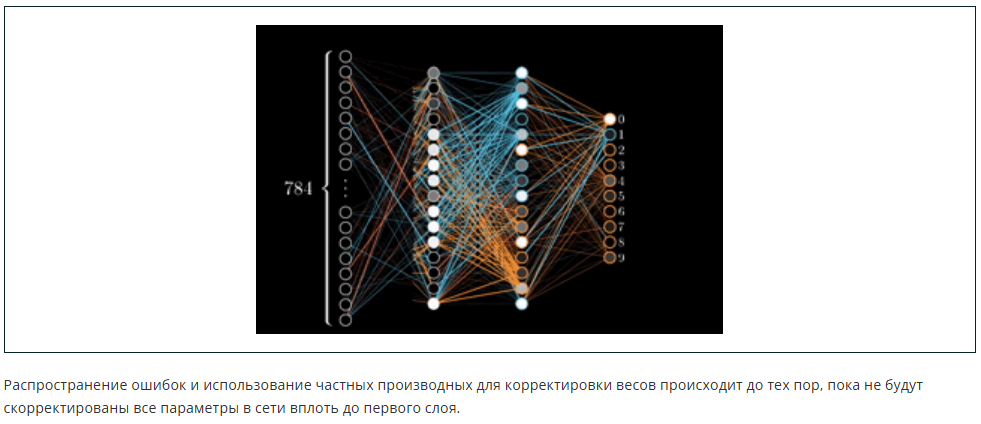

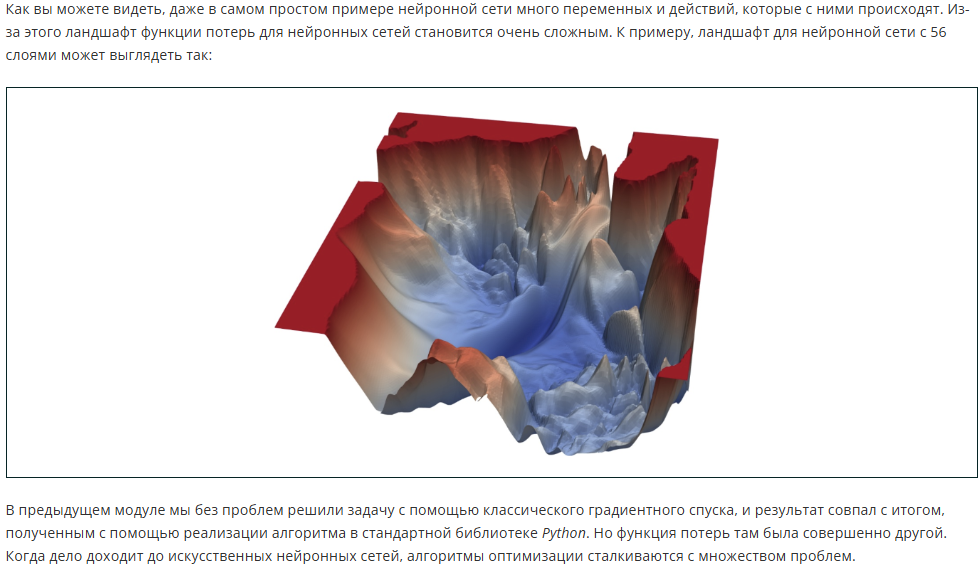

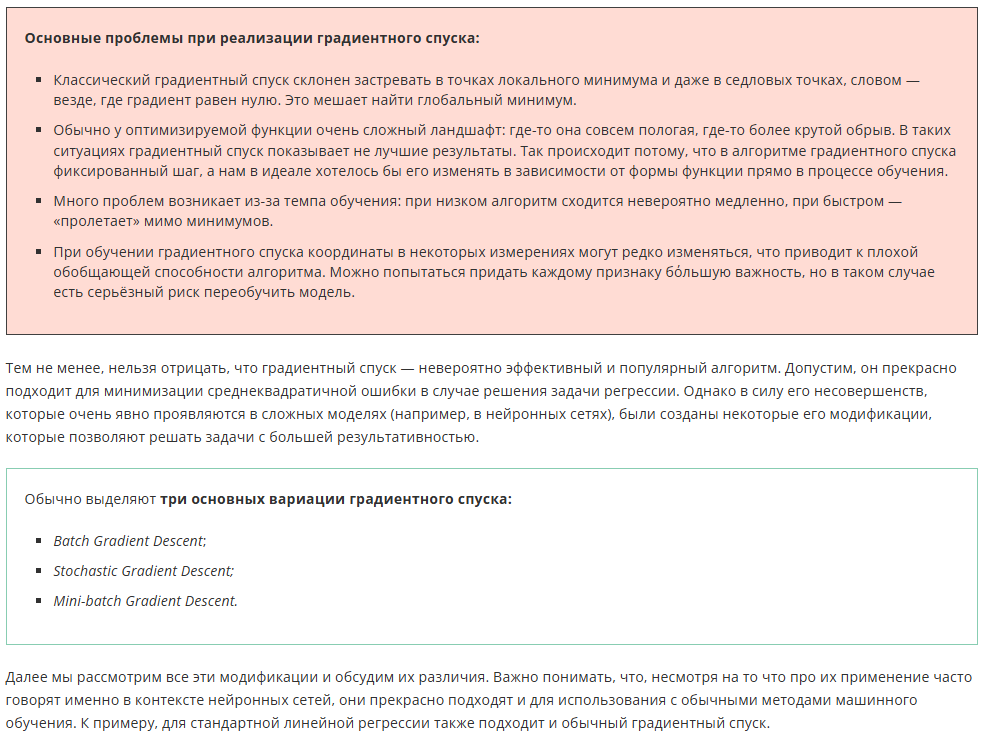

# <center> **Batch Gradient Descent**

Первая вариация — это **Batch Gradient Descent**. По-русски её называют **пакетным градиентным спуском**, или **ванильным градиентным спуском** (хотя англоязычную вариацию Vanilla Gradient Descent чаще не переводят). По сути, это и есть классический градиентный спуск, который мы с вами рассматривали в предыдущем модуле.

*Пакетным* его называют по той причине, что он использует всю выборку (весь пакет) на каждом шаге, для того чтобы получить результат.

Слово "*vanilla*" в названии используют для того, чтобы указать, что это самый простой вариант, без «примесей». В английском языке такое название может применяться не только для градиентного спуска, но и для любого метода в целом. В русском языке такое название, как правило, чаще присутствует в дословных переводах англоязычных текстов.

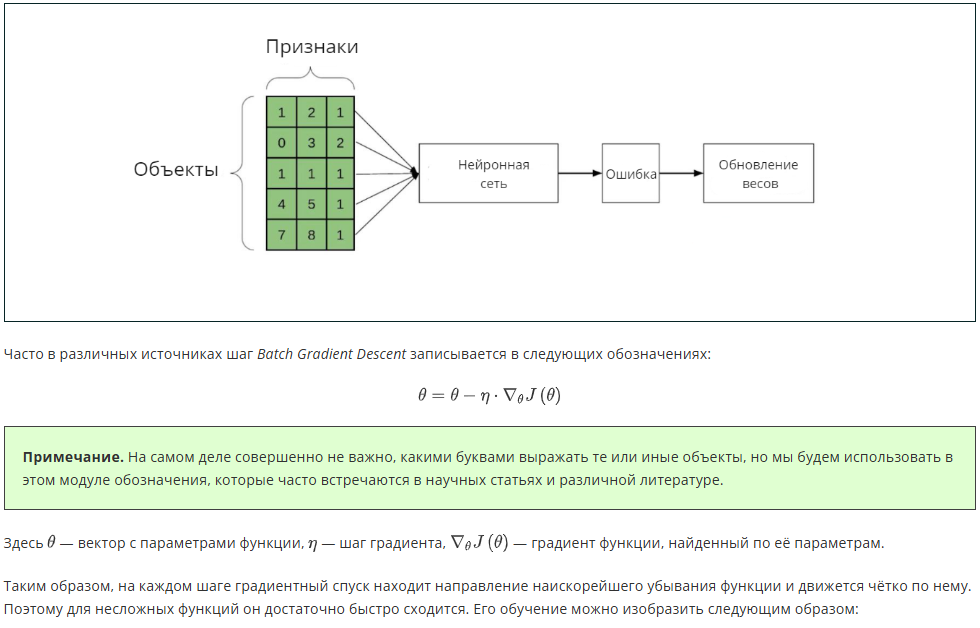

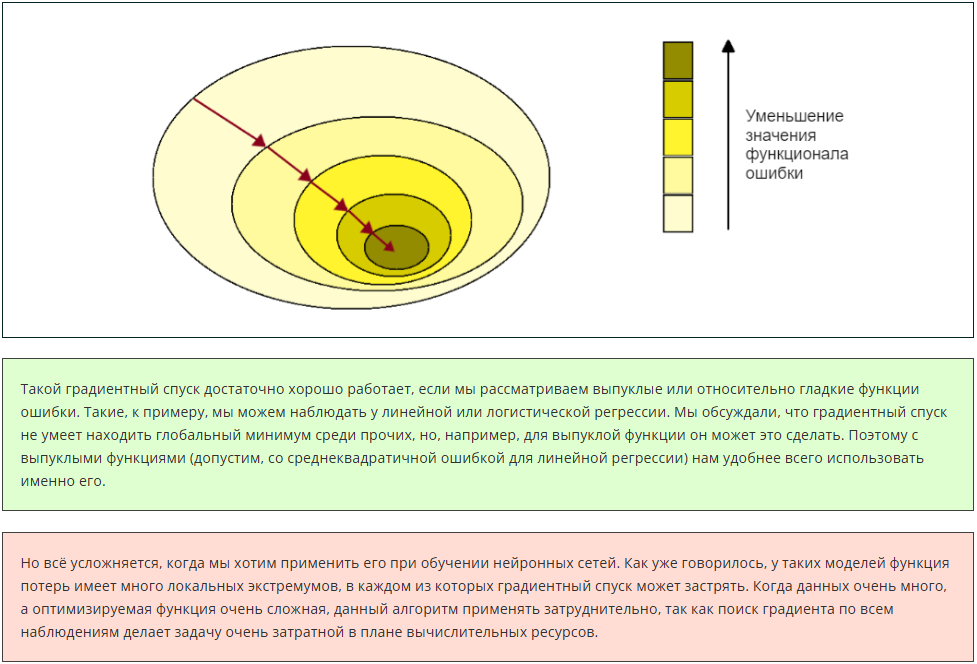

# <center> **Stochastic Gradient Descent**

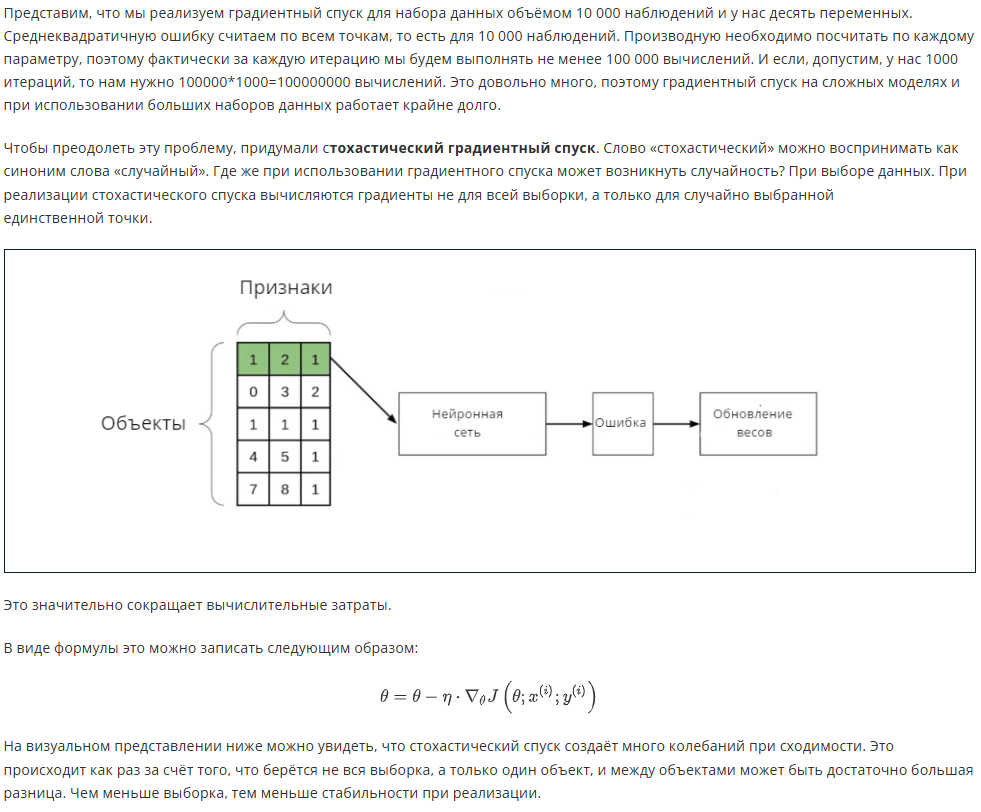

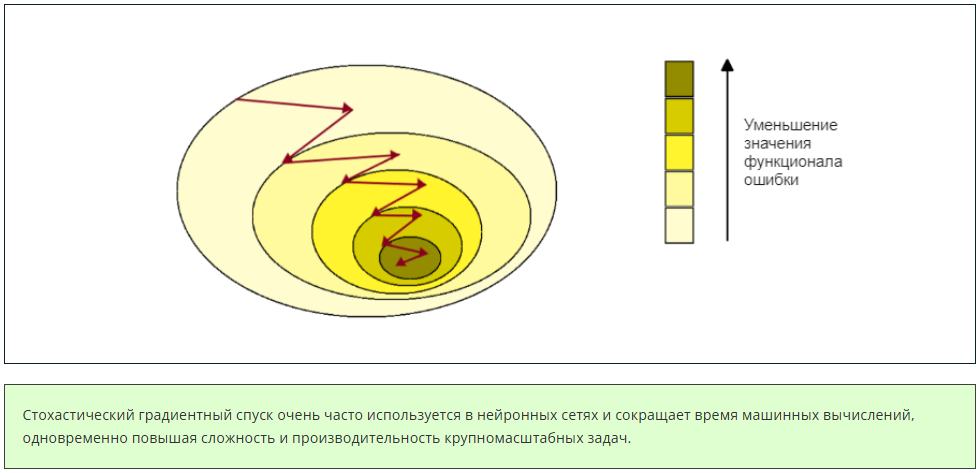

# <center> **Mini-batch Gradient Descent**

Третья вариация градиентного спуска — **Mini-batch Gradient Descent**. Также можно называть его **мини-пакетным градиентным спуском**. По сути, эта модификация сочетает в себе лучшее от классической реализации и стохастического варианта. На данный момент это наиболее популярная реализация градиентного спуска, которая используется в глубоком обучении (т. е. в обучении нейронных сетей).

В ходе обучения модели с помощью мини-пакетного градиентного спуска обучающая выборка разбивается на пакеты (**батчи**), для которых рассчитывается ошибка модели и пересчитываются веса.

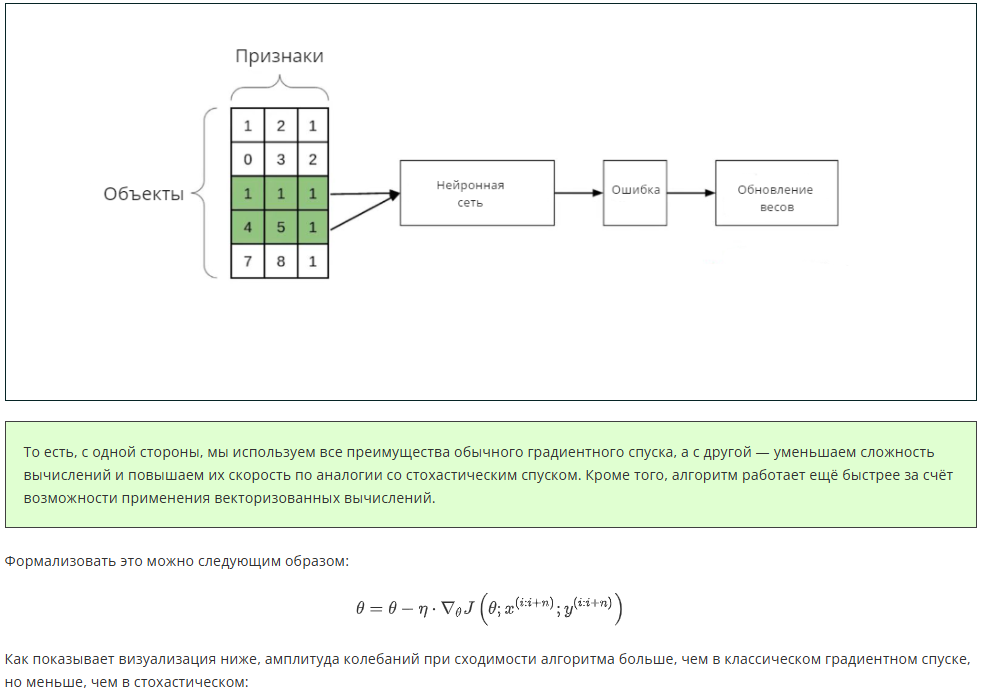

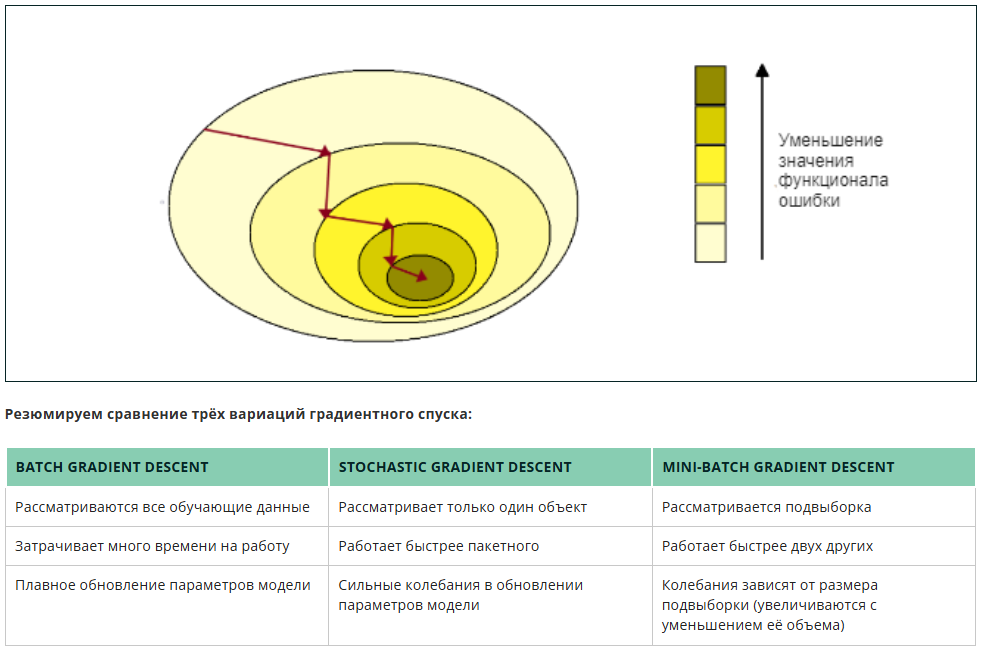

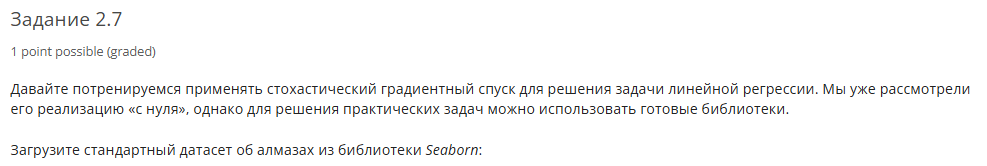

In [10]:
import seaborn as sns
import pandas as pd
import numpy as np
df = sns.load_dataset('diamonds')

Удалите часть признаков:

In [11]:
df.drop(['depth', 'table', 'x', 'y', 'z'], axis=1, inplace=True)

Закодируйте категориальные признаки:

In [12]:
df = pd.get_dummies(df, drop_first=True)

Логарифмируйте признаки:

In [13]:
df['carat'] = np.log(1+df['carat'])
df['price'] = np.log(1+df['price'])

Определите целевую переменную и предикторы:

In [14]:
X = df.drop(columns="price")
y = df["price"]

Разделите выборку на обучающую и тестовую (объём тестовой возьмите равным 0.33), значение random_state должно быть равно 42.

Теперь реализуйте алгоритм линейной регрессии со стохастическим градиентным спуском (класс SGDRegressor). Отберите с помощью GridSearchCV оптимальные параметры по следующей сетке:

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import linear_model 
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 42, test_size = 0.33)

#Сетка параметров для отбора
param_grid = {
    "loss": ["squared_error", "epsilon_insensitive"],
    "penalty": ["elasticnet"],
    "alpha": np.logspace(-3, 3, 10),
    "l1_ratio": np.linspace(0, 1, 10),
    "learning_rate": ["constant"],
    "eta0": np.logspace(-4, -1, 4)
}
#Создаём объект класса линейной регрессии с SGD
sgd_1 = linear_model.SGDRegressor(random_state=42)

# Подбор оптимальных параметров
grid_search = GridSearchCV(
    estimator=sgd_1,
    param_grid=param_grid,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

sgd_2 = linear_model.SGDRegressor(**grid_search.best_params_,random_state=42)

sgd_2.fit(X_train, y_train)

ls = sgd_2.predict(X_test)

round(mean_squared_error(y_test, ls), 3)

{'alpha': 0.001, 'eta0': 0.001, 'l1_ratio': 0.0, 'learning_rate': 'constant', 'loss': 'epsilon_insensitive', 'penalty': 'elasticnet'}


0.044

---

# Бонус: алгоритмы, основанные на градиентном спуске

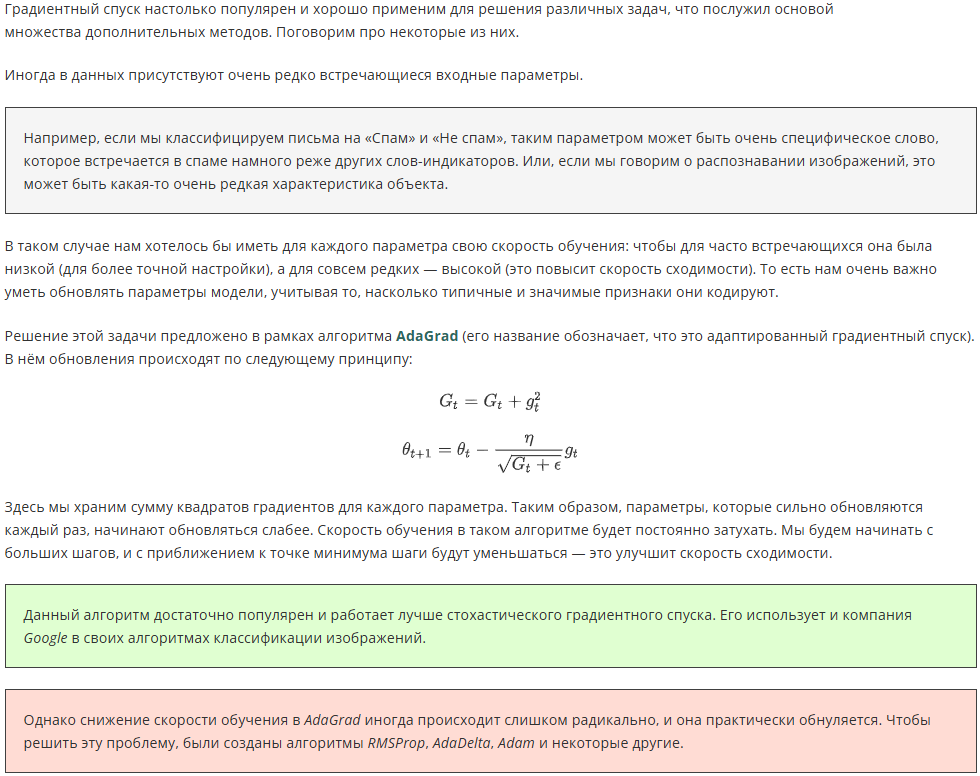

Если вам интересно подробнее узнать о перечисленных алгоритмах и окунуться в процесс оптимизации нейронных сетей, рекомендуем обратиться к следующим статьям:
* "An overview of gradient descent optimization algorithms"(скачан пдф в папке книги DS)
* [«Методы оптимизации нейронных сетей»](https://habr.com/ru/articles/318970/)

---

# <center> **Метод Ньютона**

Метод Ньютона используется во многих алгоритмах машинного обучения. Часто в литературе его сравнивают с градиентным спуском, так как два этих алгоритма очень популярны. Вы уже сталкивались с методом Ньютона, но не знали об этом.

В [документации](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) для функции ```LogisticRegression``` из библиотеки scikit-learn представлено пять вариантов алгоритмов оптимизации, которые можно использовать при обучении модели:
* 'newton-cg';
* 'lbfgs';
* 'liblinear';
* 'sag';
* 'saga'.

Последние два являются вариациями стохастического градиентного спуска (а значит вам уже понятен принцип их работы), а с первыми тремя нам только предстоит познакомиться. В этом юните мы рассмотрим алгоритм ```'newton-cg'```, в следующем — ```'lbfgs'```, а в седьмом юните — ```'liblinear'```. Вы будете понимать суть всех методов, представленных в самой популярной библиотеке для машинного обучения, и выбирать подходящий, исходя из особенностей поставленной задачи.

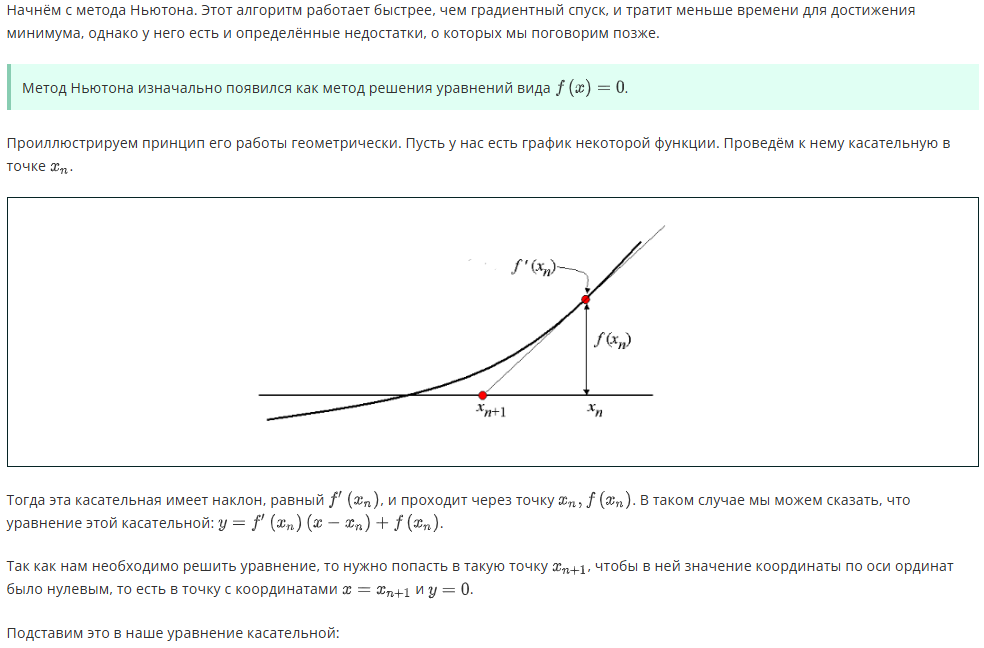

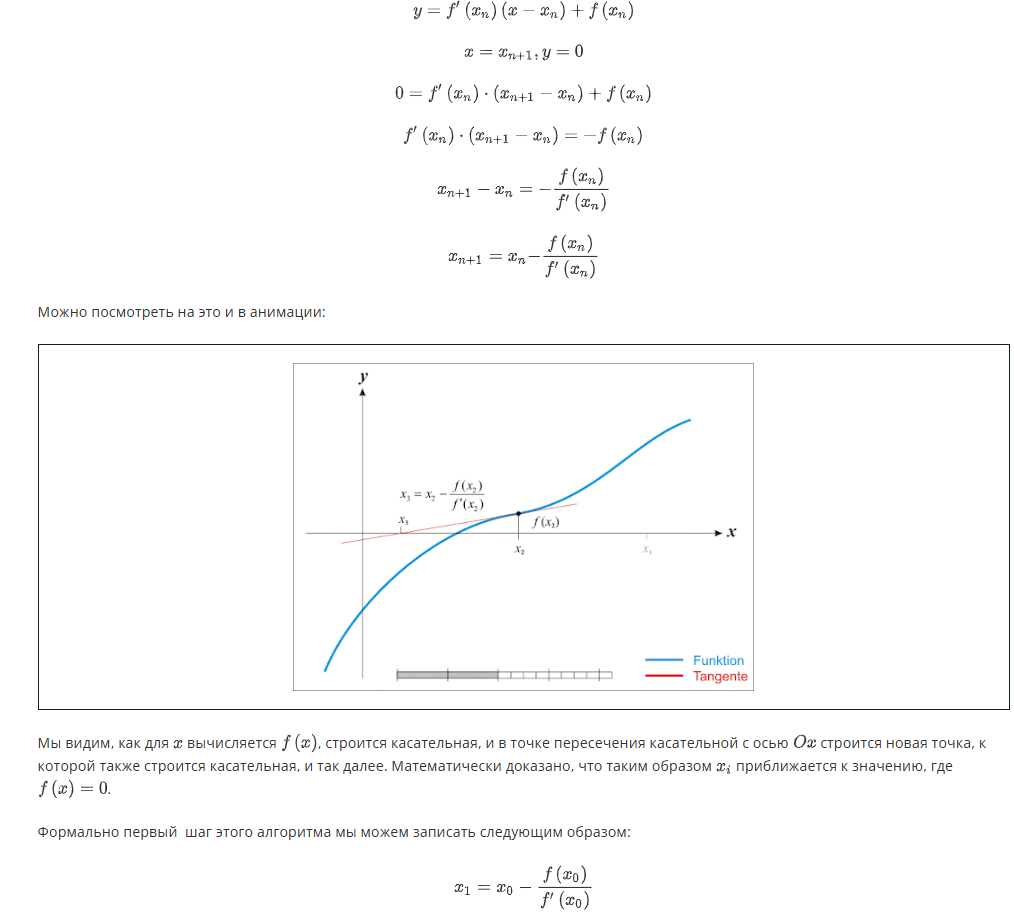

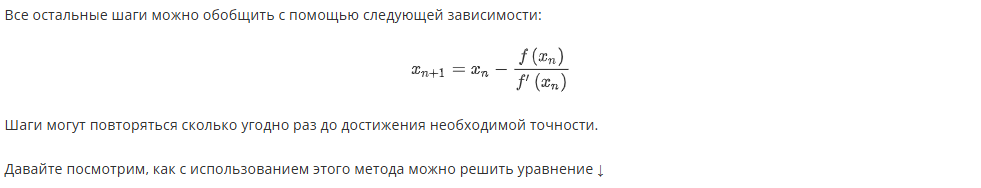

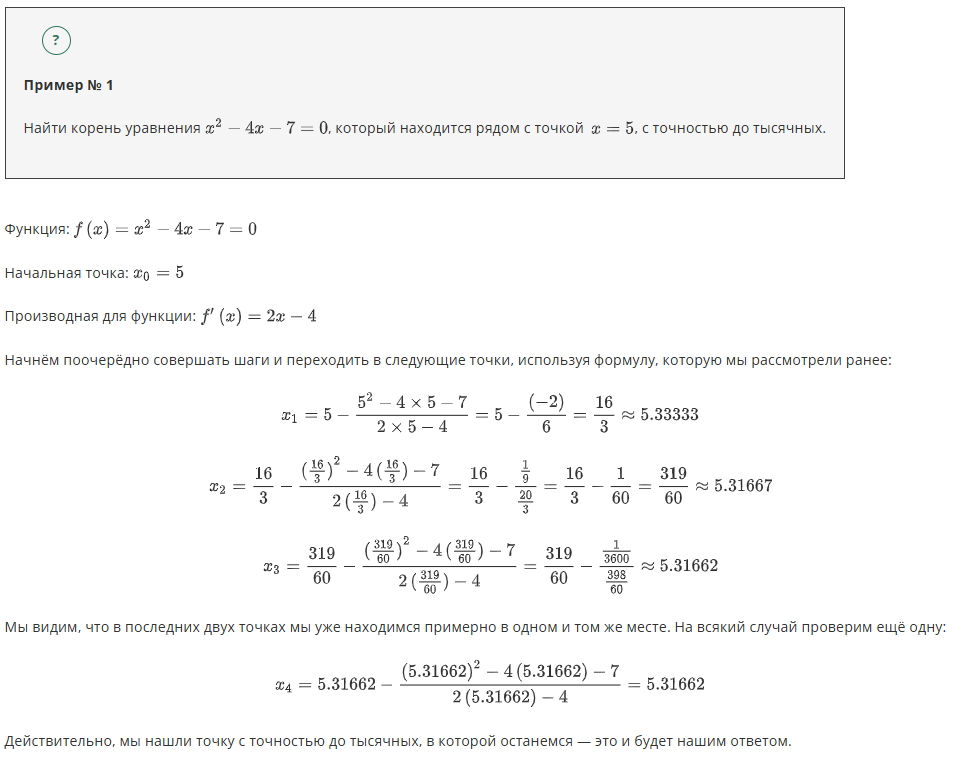

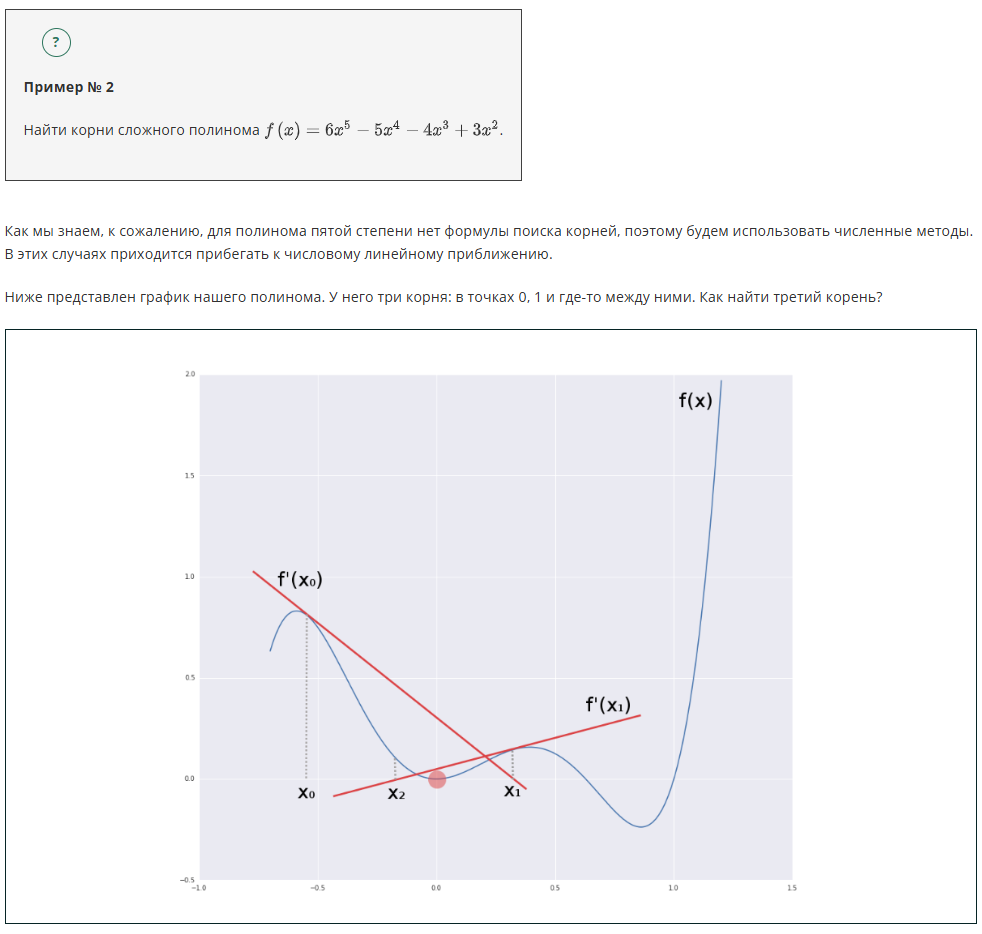

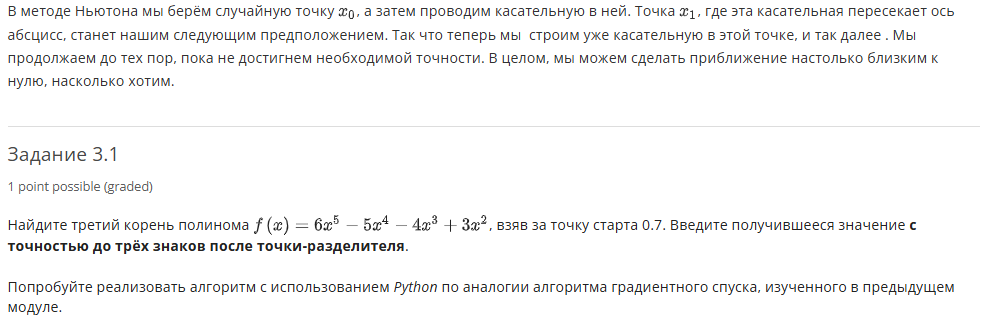

In [21]:
def fun(x):
    return 6*x**5 - 5*x**4 - 4*x**3 + 3*x**2

def grad(x):
    dx=30*x**4 - 20*x**3 - 12*x**2 + 6*x
    return dx

In [39]:
x_0=0.7
x_list = [0.7]
i = 0
while True:
    x_new=x_0 - fun(x_0)/grad(x_0)
    x_new=round(x_new,4)
    x_list.append(x_new)
    x_0=x_new
    i += 1
    print(f"iter={i}; x_list: {x_list}")
    if x_list[-1]==x_list[-2]:
        break

iter=1; x_list: [0.7, 0.6296]
iter=2; x_list: [0.7, 0.6296, 0.6287]
iter=3; x_list: [0.7, 0.6296, 0.6287, 0.6287]


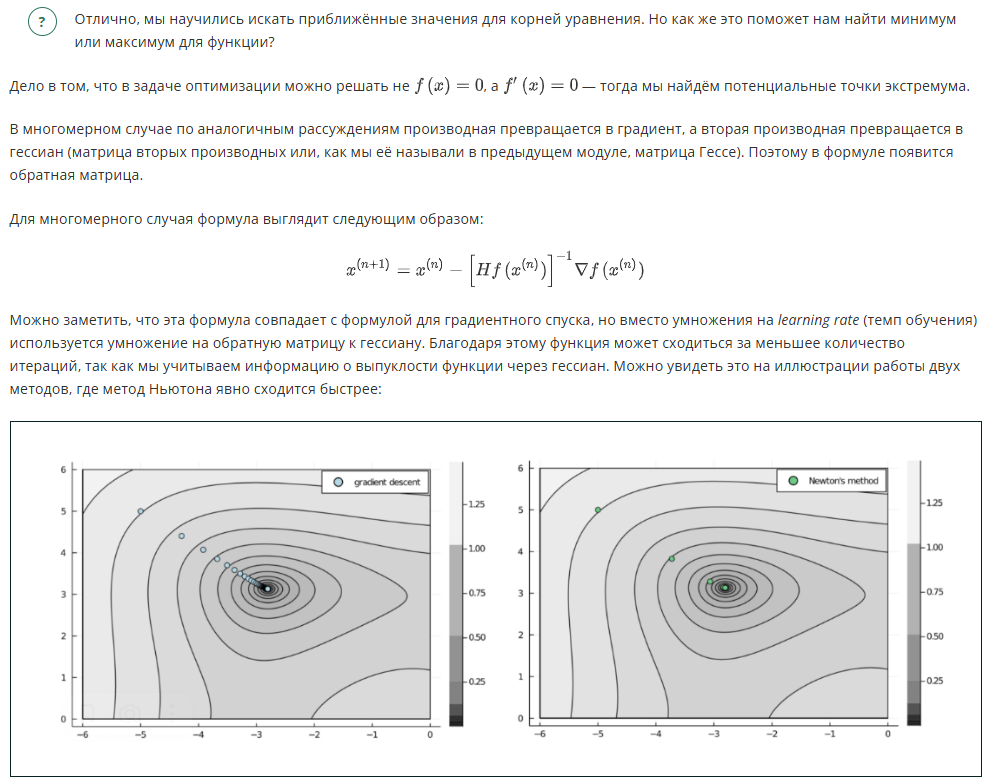

Метод Ньютона, если считать в количестве итераций, в многомерном случае (с гессианом) работает быстрее градиентного спуска.

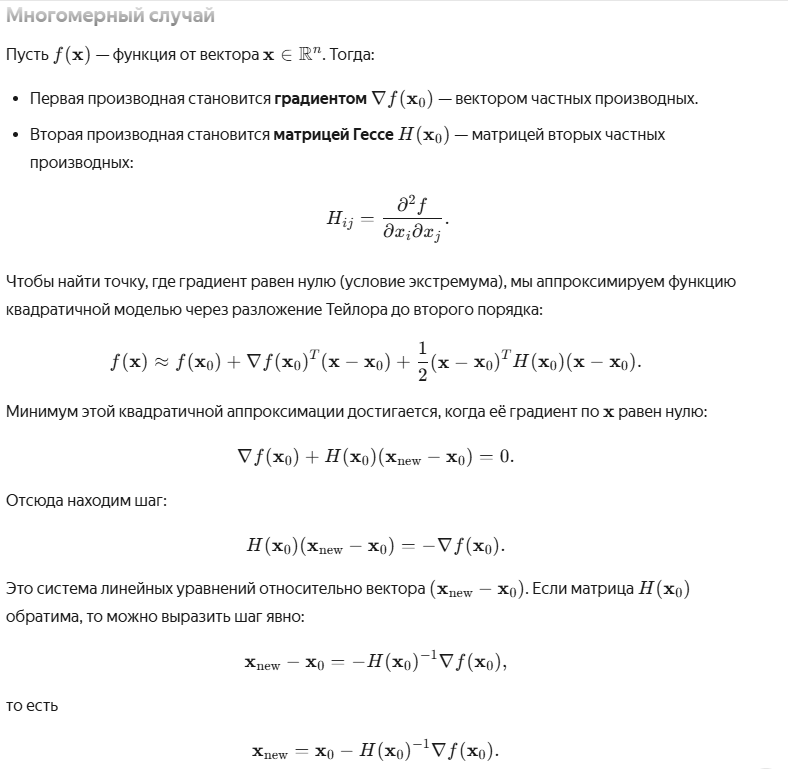

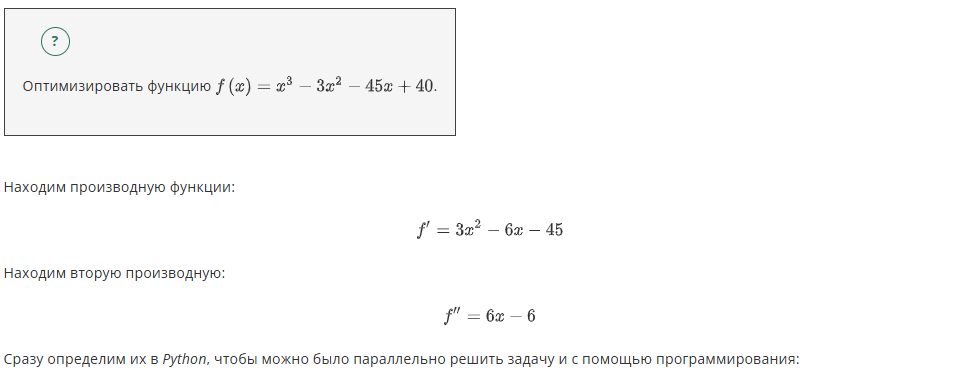

In [40]:
def func1(x):
    return 3*x**2 - 6*x -45
def func2(x):
    return 6*x - 6

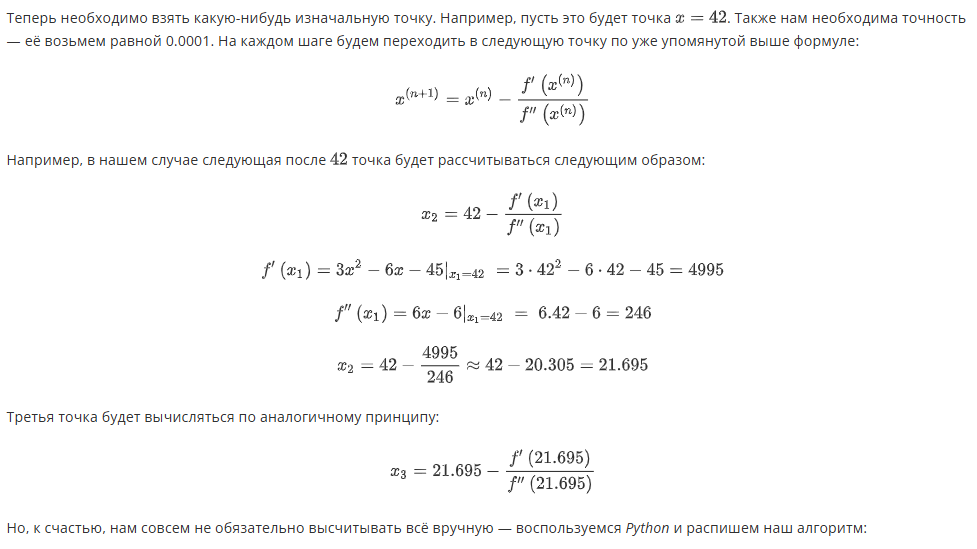

In [41]:
initial_value = 42
iter_count = 0
x_curr = initial_value
epsilon = 0.0001
f = func1(x_curr)

while (abs(f) > epsilon):
    f = func1(x_curr)
    f_prime = func2(x_curr)
    x_curr = x_curr - (f)/(f_prime)
    iter_count += 1
    print(x_curr)

21.695121951219512
11.734125501243229
7.1123493600499685
5.365000391507974
5.015260627016227
5.000029000201801
5.000000000105126
5.000000000000001


Можно объединить всё в одну функцию:

In [42]:
def newtons_method(f, fprime, x0, tol=0.0001):
    iter_count = 0
    x_curr = x0
    f_val = f(x_curr)
    while (abs(f_val) > tol):
        f_val = f(x_curr)
        f_prime_val = fprime(x_curr)
        x_curr = x_curr - (f_val)/(f_prime_val)
        iter_count += 1
    return x_curr

newtons_method(f=func1, fprime=func2, x0=50, tol=0.0001)

5.0

А можно воспользоваться реализацией из библиотеки scipy:

In [43]:
from scipy.optimize import newton
newton(func=func1, fprime=func2, x0=50, tol=0.0001)

5.0

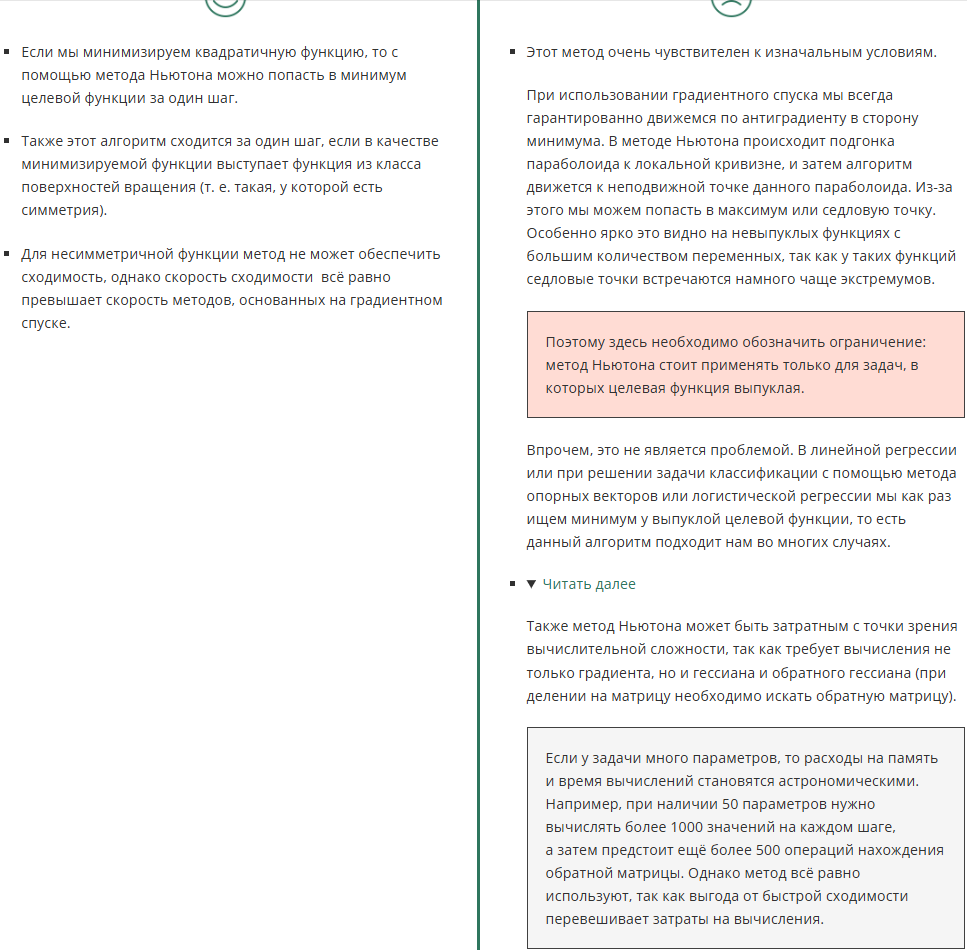

Несмотря на его ограниченное практическое применение, метод Ньютона по-прежнему представляет большую ценность. Он имеет большое преимущество перед градиентным спуском в силу своей быстроты и отсутствия необходимости в настройке гиперпараметра шага (мы помним, что в градиентном спуске выбор шага — довольно непростая задача, а здесь можно обойтись без этого). Причём преимущество в быстроте очень ощутимое: [в сравнении на реальных данных](https://www.researchgate.net/publication/352122891_Application_of_Newton's_method_to_solve_optimization_geodetic_tasks) метод Ньютона находит решение задачи за 3 итерации, а градиентный спуск — за 489. То есть мы сильно выигрываем в скорости сходимости, а для анализа данных это очень важно, ведь экономия времени и вычислительных ресурсов позволяет решать задачи быстрее.

Мы увидели, какой эффективной может быть оптимизация второго порядка при правильном использовании. Но что, если бы мы могли каким-то образом использовать эффективность, полученную при использовании производных второго порядка, но при этом избежать вычислительных затрат на вычисление обратного гессиана? Другими словами — можем ли мы создать алгоритм, который будет своего рода гибридом между градиентным спуском и методом Ньютона, где мы сможем получать более быструю сходимость, чем градиентный спуск, но меньшие вычислительные затраты на каждую итерацию, чем в методе Ньютона?

Оказывается, такой алгоритм существует. Точнее, целый класс таких методов оптимизации, называемых **квазиньютоновскими методами**

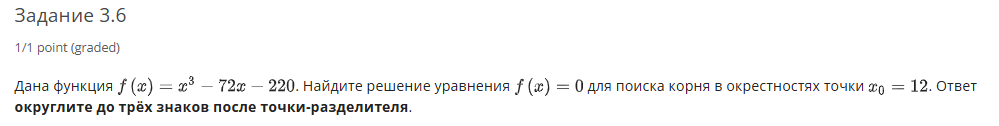

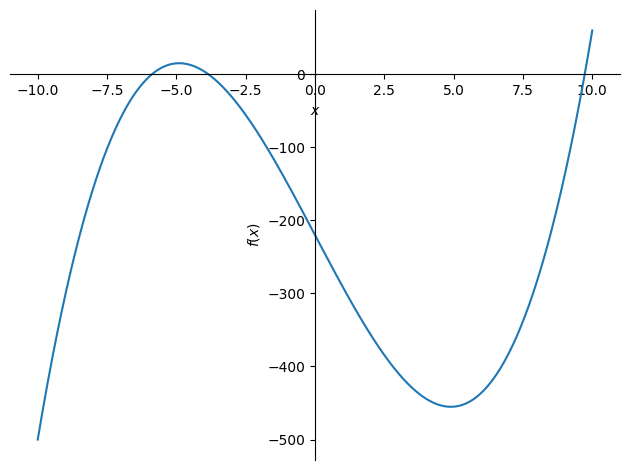

In [46]:
from sympy import *
x = symbols('x')
f = x**3 - 72*x - 220
plot(f)

In [50]:
def fun(x):
    return x**3 - 72 * x - 220

def grad(x):
    dx=3*x**2 - 72
    return dx

In [51]:
x_0=12
x_list = [12]
i = 0
while True:
    x_new=x_0 - fun(x_0)/grad(x_0)
    x_new=round(x_new,3)
    x_list.append(x_new)
    x_0=x_new
    i += 1
    print(f"iter={i}; x_list: {x_list}")
    if x_list[-1]==x_list[-2]:
        break

iter=1; x_list: [12, 10.211]
iter=2; x_list: [12, 10.211, 9.756]
iter=3; x_list: [12, 10.211, 9.756, 9.727]
iter=4; x_list: [12, 10.211, 9.756, 9.727, 9.727]


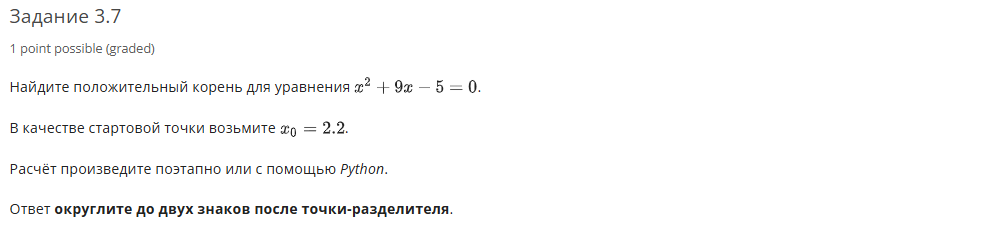

In [57]:
def fun(x):
    return x**2 + 9 * x - 5

def grad(x):
    dx=32*x + 9
    return dx

x_0=2.2
x_list = [2.2]
i = 0
while True:
    x_new=x_0 - fun(x_0)/grad(x_0)
    x_new=round(x_new,3)
    x_list.append(x_new)
    x_0=x_new
    i += 1
    print(f"iter={i}; x_list: {x_list}")
    if x_list[-1]==x_list[-2]:
        break

iter=1; x_list: [2.2, 1.953]
iter=2; x_list: [2.2, 1.953, 1.724]
iter=3; x_list: [2.2, 1.953, 1.724, 1.514]
iter=4; x_list: [2.2, 1.953, 1.724, 1.514, 1.324]
iter=5; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155]
iter=6; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009]
iter=7; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885]
iter=8; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785]
iter=9; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706]
iter=10; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647]
iter=11; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647, 0.605]
iter=12; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647, 0.605, 0.576]
iter=13; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0.785, 0.706, 0.647, 0.605, 0.576, 0.557]
iter=14; x_list: [2.2, 1.953, 1.724, 1.514, 1.324, 1.155, 1.009, 0.885, 0

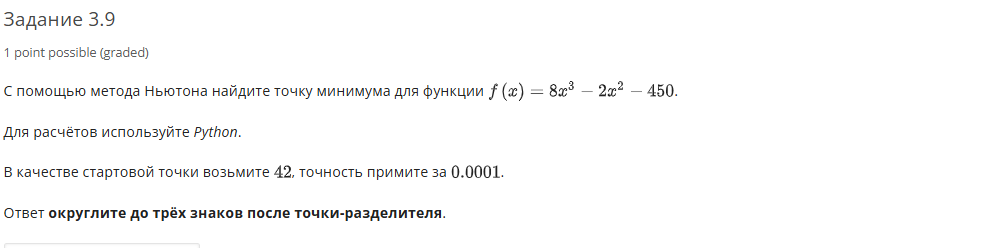

In [68]:
def newtons_method(f, fprime, x0, tol=0.0001):
    iter_count = 0
    x_curr = x0
    f_val = f(x_curr)
    while (abs(f_val) > tol):
        f_val = f(x_curr)
        f_prime_val = fprime(x_curr)
        x_curr = x_curr - (f_val)/(f_prime_val)
        iter_count += 1
    return round(x_curr, 3)

def func1(x):
    return 24*x**2 - 4*x 
def func2(x):
    return 48*x - 4

newtons_method(f=func1, fprime=func2, x0=42, tol=0.0001)

0.167

---

# <center> **Квазиньютоновские методы**

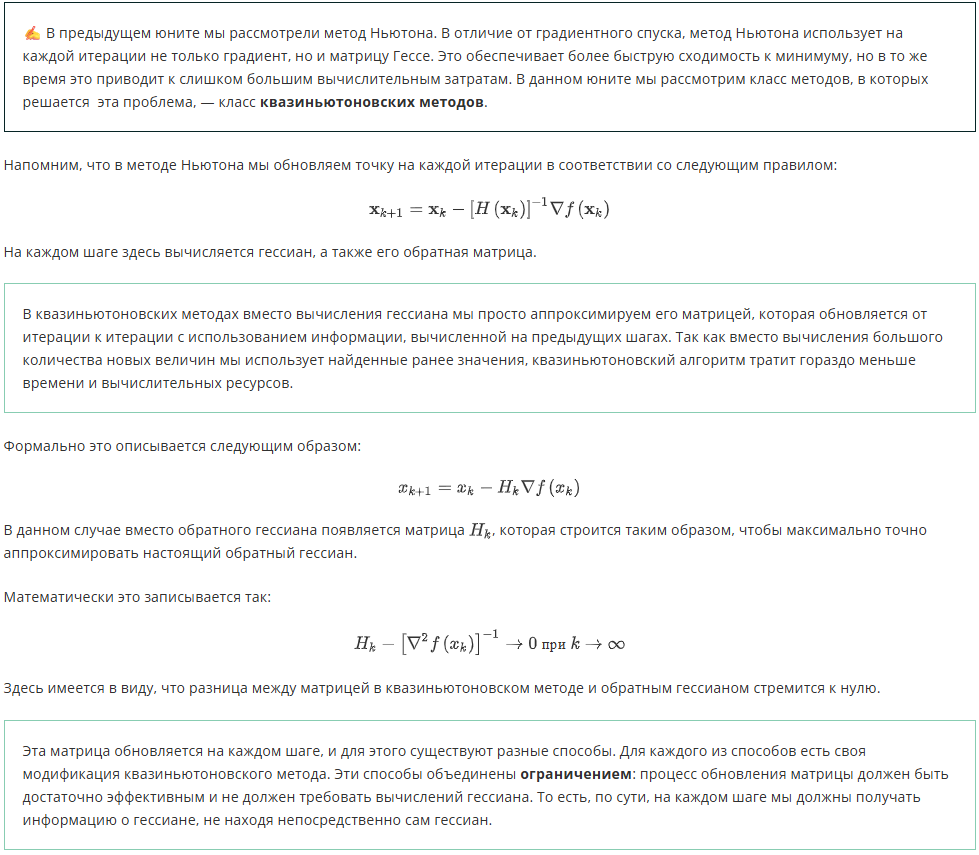

>Если вас интересует математическая сторона обновления и аппроксимации матрицы, прочитайте эту статью ("D:\Книги\DS\Квазиньютоновские методы.pdf"). В силу того, что понимание этой части метода требует очень серьёзной математической подготовки, мы опустим её. Однако можем заверить вас, что для успешного использования алгоритма и его понимания знание всех математических выводов не требуется.

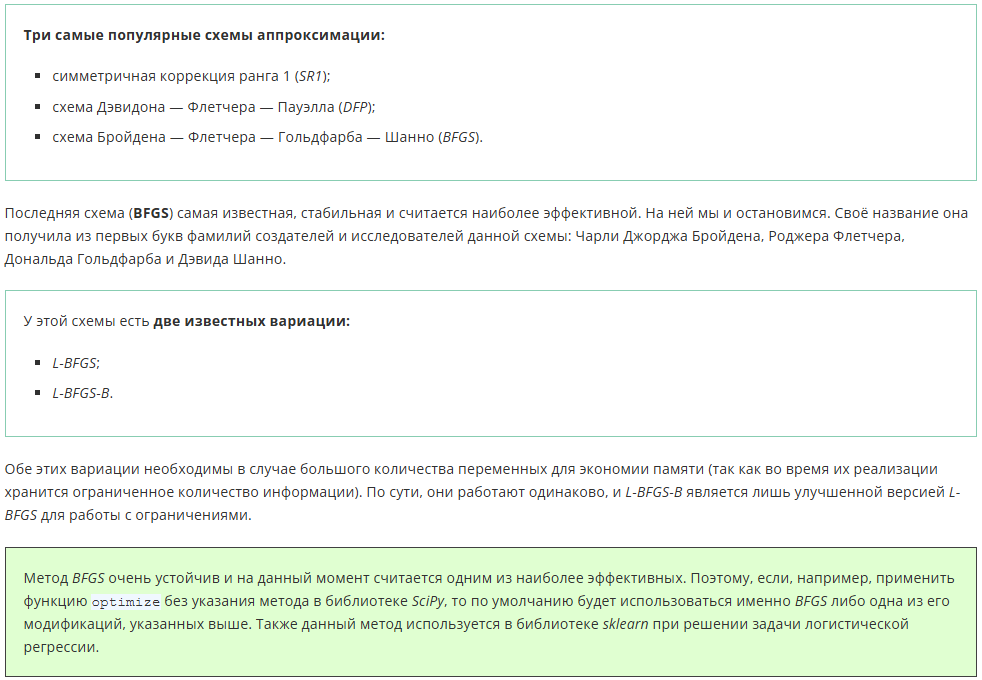

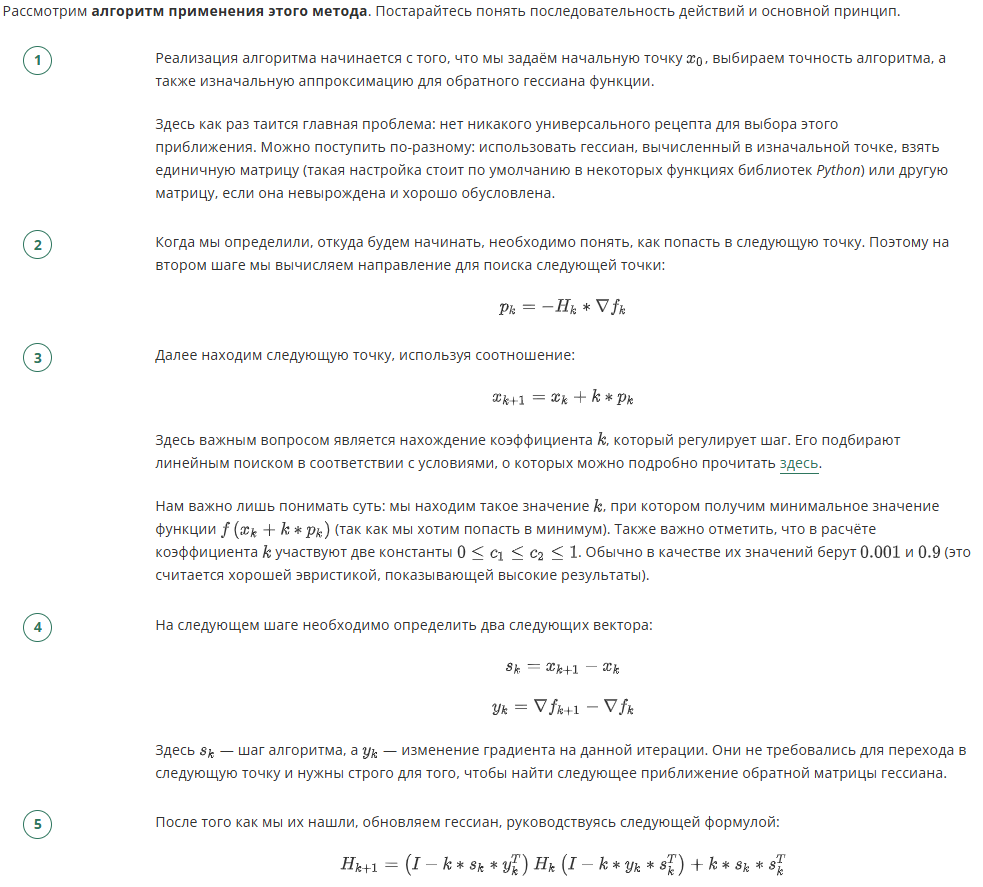

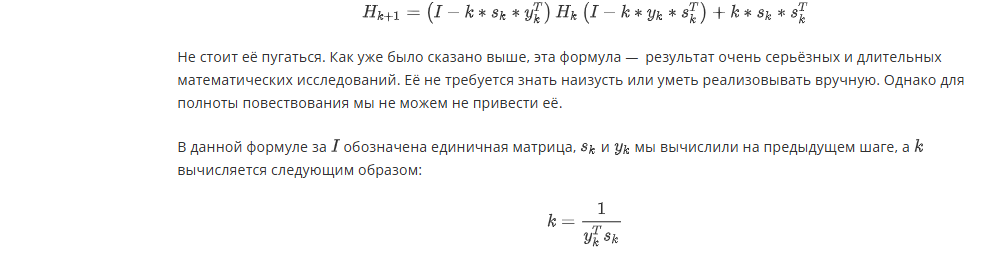

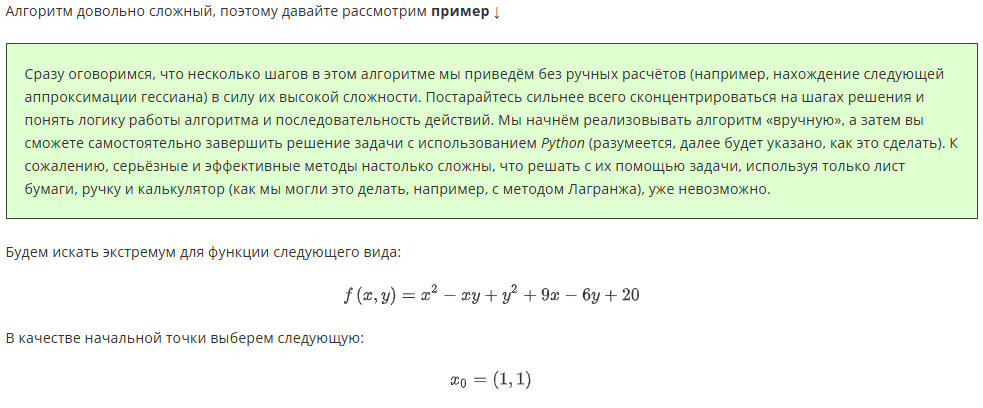

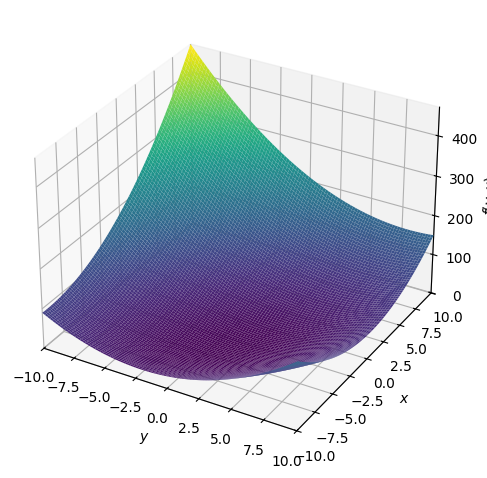

In [1]:
from sympy import *
from sympy.plotting import plot3d

x, y = symbols('x y')
f=x**2 - x*y + y**2 + 9 *x - 6*y +20
plot3d(f)

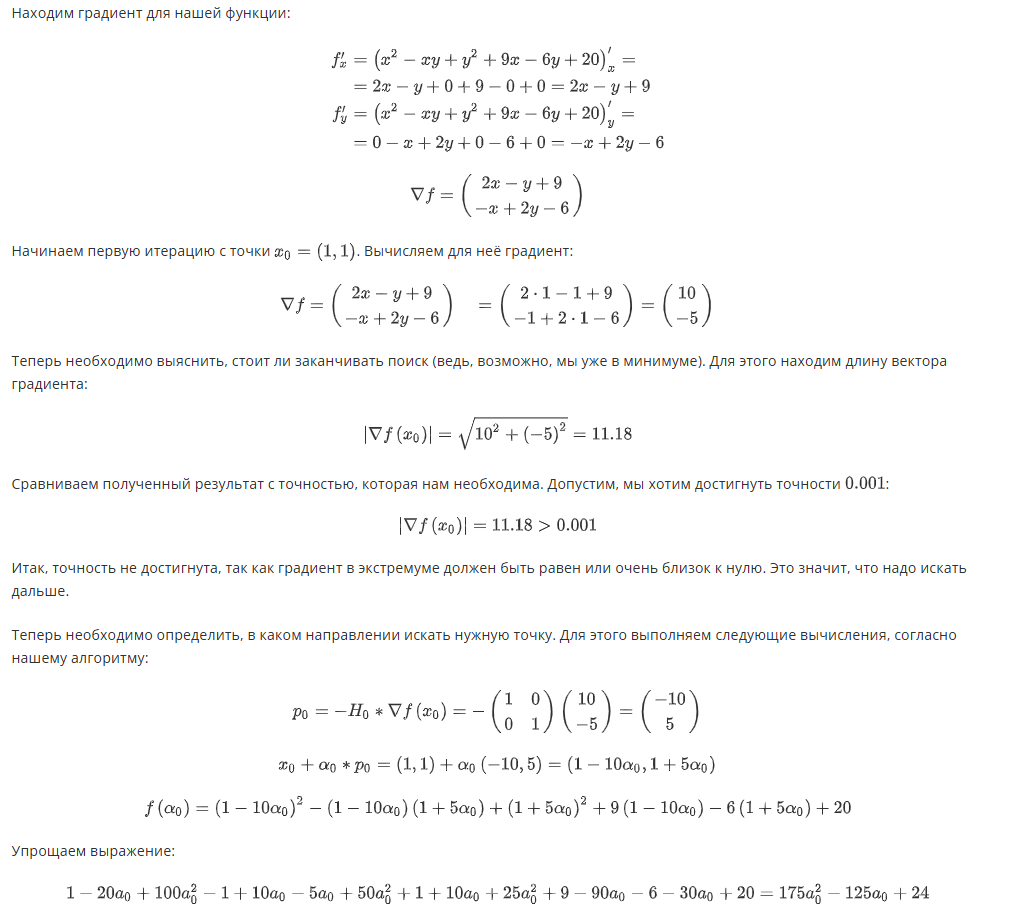

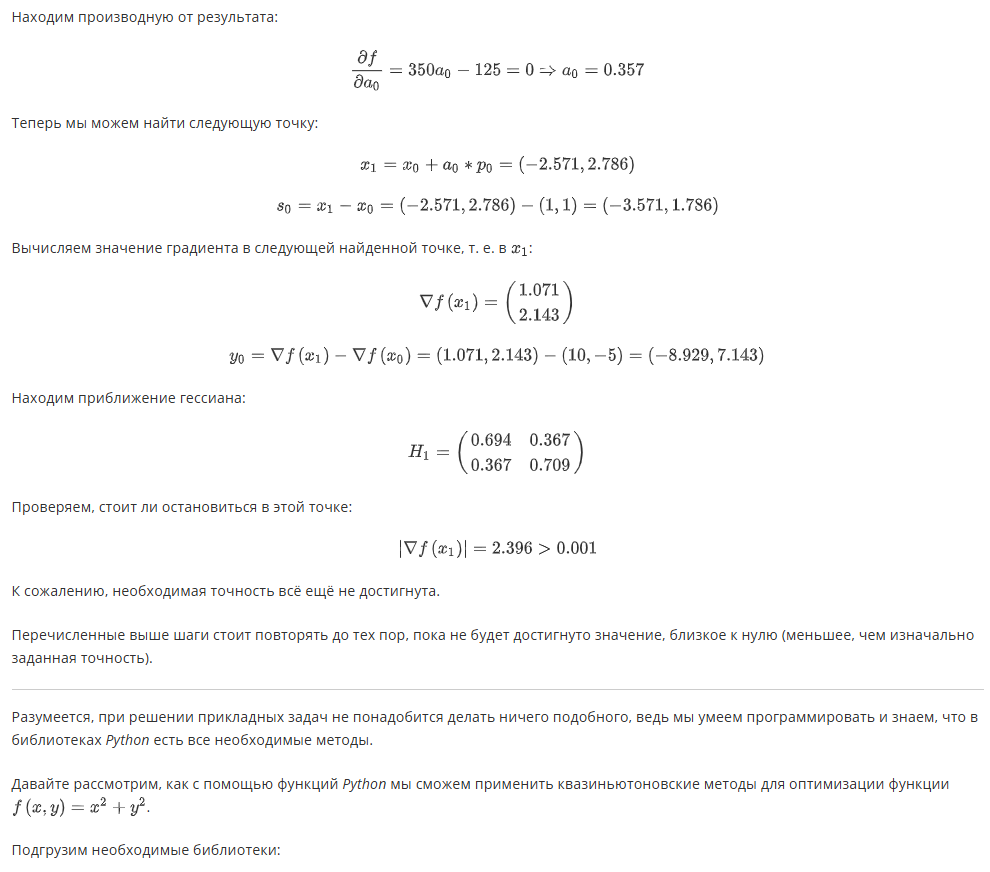

In [2]:
import numpy as np
from scipy.optimize import minimize

Определим функцию, которую будем оптимизировать. Вместо отдельных x и y можно взять координаты единого вектора:

In [3]:
def func(x):
    return x[0]**2.0 + x[1]**2.0

Теперь определим градиент для функции:

In [4]:
def grad_func(x):
    return np.array([x[0] * 2, x[1] * 2])

Зададим начальную точку:

In [5]:
x_0 = [1.0, 1.0]

Определим алгоритм:

In [6]:
result = minimize(func, x_0, method='BFGS', jac=grad_func)

Выведем результаты:

In [7]:
print('Статус оптимизации %s' % result['message'])
print('Количество оценок: %d' % result['nfev'])
solution = result['x']
evaluation = func(solution)
print('Решение: f(%s) = %.5f' % (solution, evaluation))

Статус оптимизации Optimization terminated successfully.
Количество оценок: 3
Решение: f([0. 0.]) = 0.00000


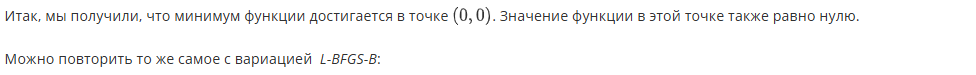

In [8]:
# определяем нашу функцию
def func(x):
    return x[0]**2.0 + x[1]**2.0
 
#  определяем градиент функции
def grad_func(x):
    return np.array([x[0] * 2, x[1] * 2])
 
# определяем начальную точку
x_0 = [1, 1]
# реализуем алгоритм L-BFGS-B
result = minimize(func, x_0, method='L-BFGS-B', jac=grad_func)
# получаем результат
print('Статус оптимизации %s' % result['message'])
print('Количество оценок: %d' % result['nfev'])
solution = result['x']
evaluation = func(solution)
print('Решение: f(%s) = %.5f' % (solution, evaluation))

Статус оптимизации CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Количество оценок: 3
Решение: f([0. 0.]) = 0.00000


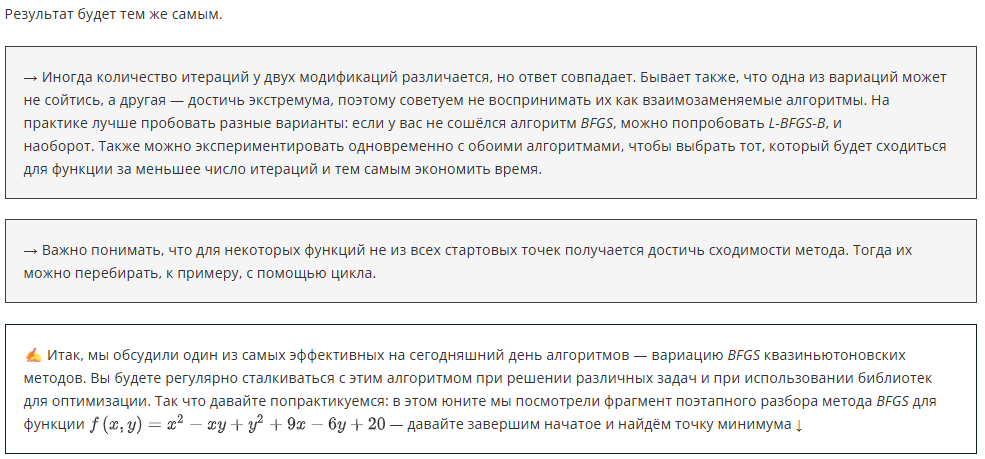

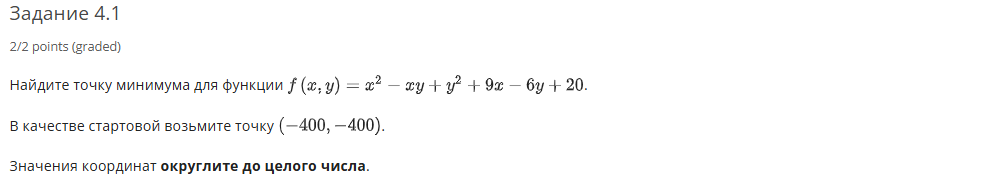

In [11]:
# определяем нашу функцию
def func(x):
    return x[0]**2.0 - x[0]*x[1] + x[1]**2 + 9*x[0] - 6*x[1] + 20
 
#  определяем градиент функции
def grad_func(x):
    return np.array([2*x[0] - x[1] + 9, 2*x[1] - x[0] - 6])
 
# определяем начальную точку
x_0 = [-400, -400]
# реализуем алгоритм L-BFGS-B
result = minimize(func, x_0, method='L-BFGS-B', jac=grad_func)
# получаем результат
print('Статус оптимизации %s' % result['message'])
print('Количество оценок: %d' % result['nfev'])
solution = result['x']
evaluation = func(solution)
print('Решение: f(%s) = %.0f' % (solution, evaluation))

Статус оптимизации CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Количество оценок: 9
Решение: f([-3.99999972  1.00000028]) = -1


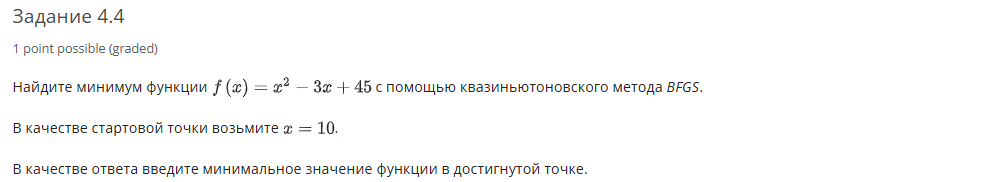

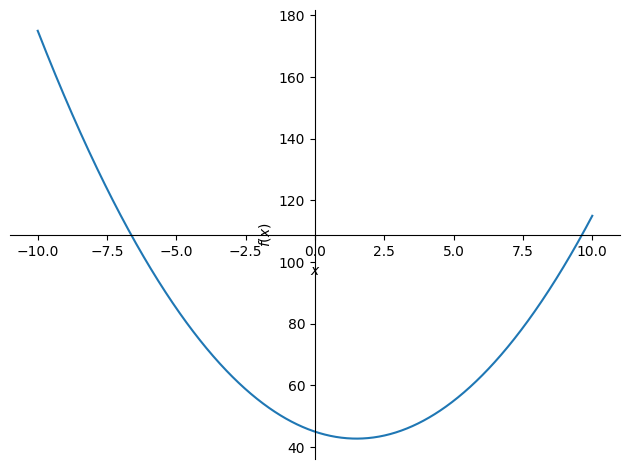

In [13]:
from sympy import *
x = symbols('x')
f = x**2 - 3*x + 45
plot(f)

In [19]:
# определяем нашу функцию
def func(x):
    return x**2 - 3*x + 45
 
#  определяем градиент функции
def grad_func(x):
    return 2*x - 3

# определяем начальную точку
x_0 = 10

result = minimize(func, x_0, method='BFGS', jac=grad_func)

print('Количество оценок: %d' % result['nfev'])
solution = result['x']
evaluation = func(solution)
print('Решение: f(%s) = %.5f' % (solution, evaluation))

Количество оценок: 5
Решение: f([1.5]) = 42.75000


In [14]:
# определяем нашу функцию
def func(x):
    return x**2 - 3*x + 45
 
#  определяем градиент функции
def grad_func(x):
    return np.array([2*x - 3])
 
# определяем начальную точку
x_0 = 10
# реализуем алгоритм L-BFGS-B
result = minimize(func, x_0, method='L-BFGS-B', jac=grad_func)
# получаем результат
print('Статус оптимизации %s' % result['message'])
print('Количество оценок: %d' % result['nfev'])
solution = result['x']
evaluation = func(solution)
print('Решение: f(%s) = %.3f' % (solution, evaluation))

Статус оптимизации CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Количество оценок: 3
Решение: f([1.5]) = 42.750


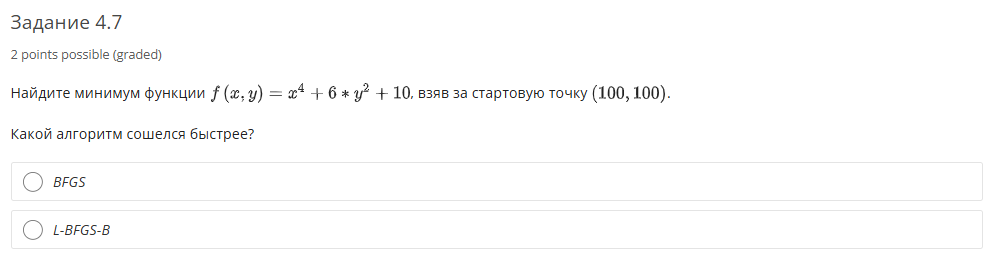

method='BFGS'

In [21]:
# определяем нашу функцию
def func(x):
    return x[0]**4 + 6*x[1]**2 + 10
 
#  определяем градиент функции
def grad_func(x):
    return np.array([4*x[0]**3, 12*x[1]])

# определяем начальную точку
x_0 = [100, 100]

result = minimize(func, x_0, method='BFGS', jac=grad_func)

print('Количество оценок: %d' % result['nfev'])
solution = result['x']
evaluation = func(solution)
print('Решение: f(%s) = %.5f' % (solution, evaluation))

Количество оценок: 37
Решение: f([1.31617159e-02 6.65344582e-14]) = 10.00000


method='L-BFGS-B'

In [22]:
# определяем нашу функцию
def func(x):
    return x[0]**4 + 6*x[1]**2 + 10
 
#  определяем градиент функции
def grad_func(x):
    return np.array([4*x[0]**3, 12*x[1]])
 
# определяем начальную точку
x_0 = [100, 100]
# реализуем алгоритм L-BFGS-B
result = minimize(func, x_0, method='L-BFGS-B', jac=grad_func)
# получаем результат
print('Статус оптимизации %s' % result['message'])
print('Количество оценок: %d' % result['nfev'])
solution = result['x']
evaluation = func(solution)
print('Решение: f(%s) = %.3f' % (solution, evaluation))

Статус оптимизации CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Количество оценок: 40
Решение: f([-9.52718297e-03 -2.32170510e-06]) = 10.000


---

# <center> **Линейное программирование**

>**Линейное программирование** — это метод оптимизации для системы линейных ограничений и линейной целевой функции. Целевая функция определяет оптимизируемую величину, и цель линейного программирования состоит в том, чтобы найти значения переменных, которые максимизируют или минимизируют целевую функцию.

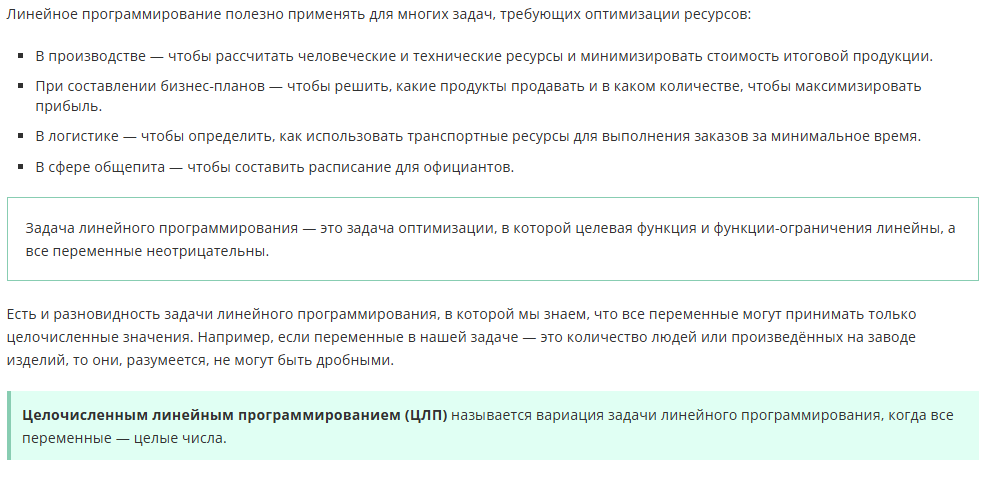

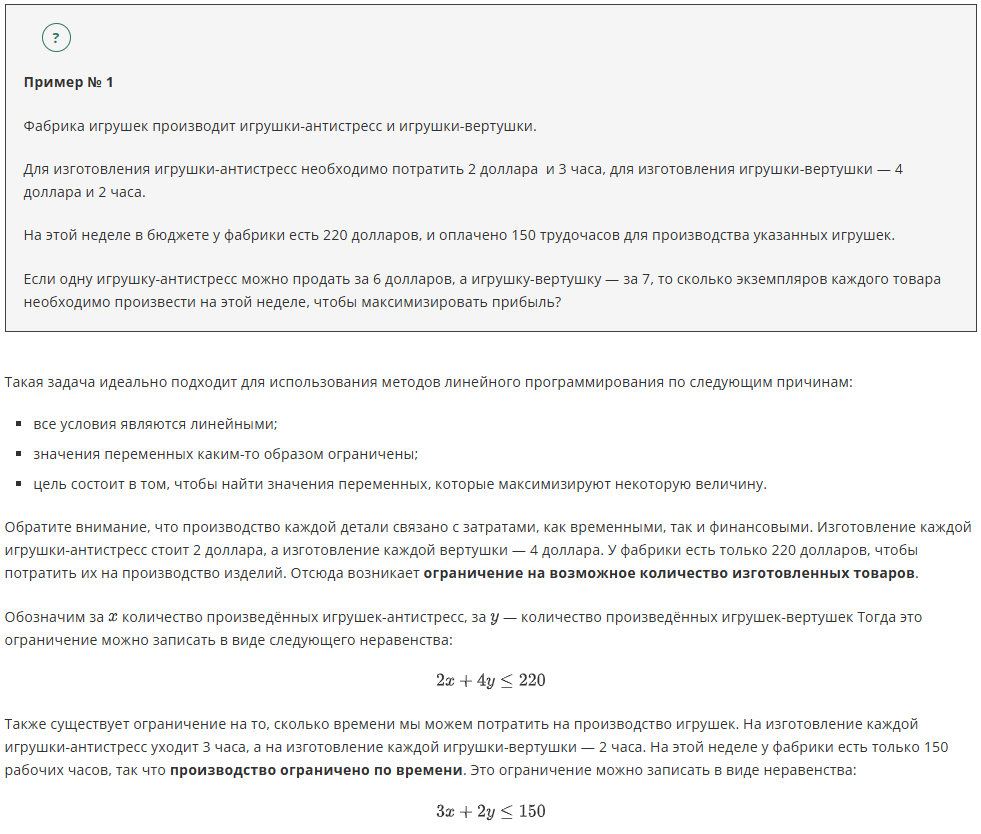

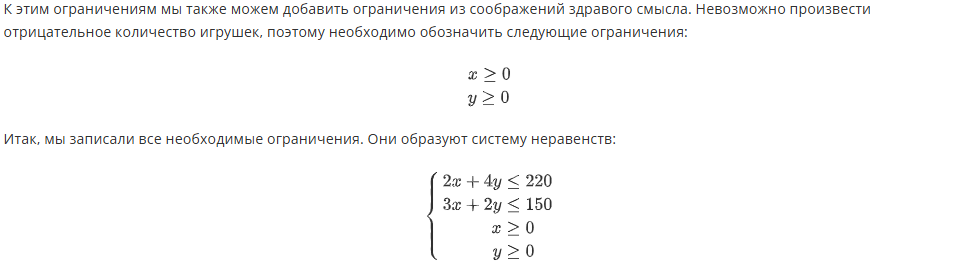

Если [представить систему этих неравенств в графическом виде](https://mathprofi.ru/lineinye_neravenstva.html), получим многоугольник:

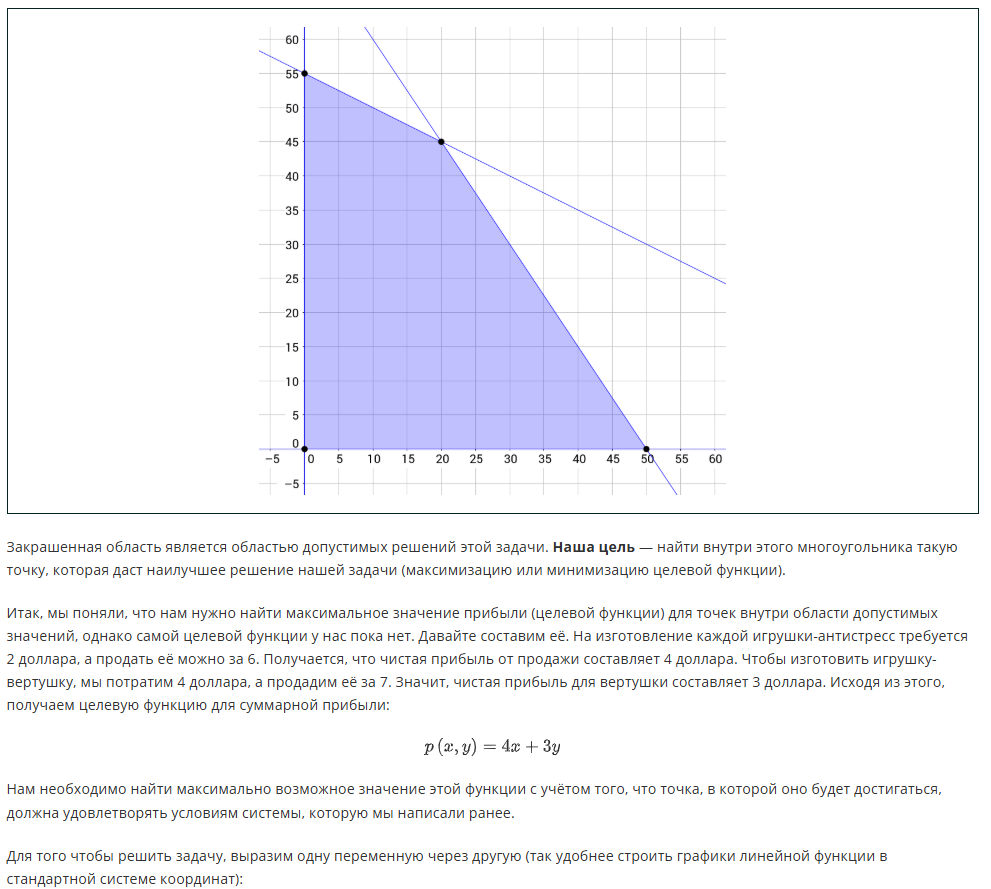

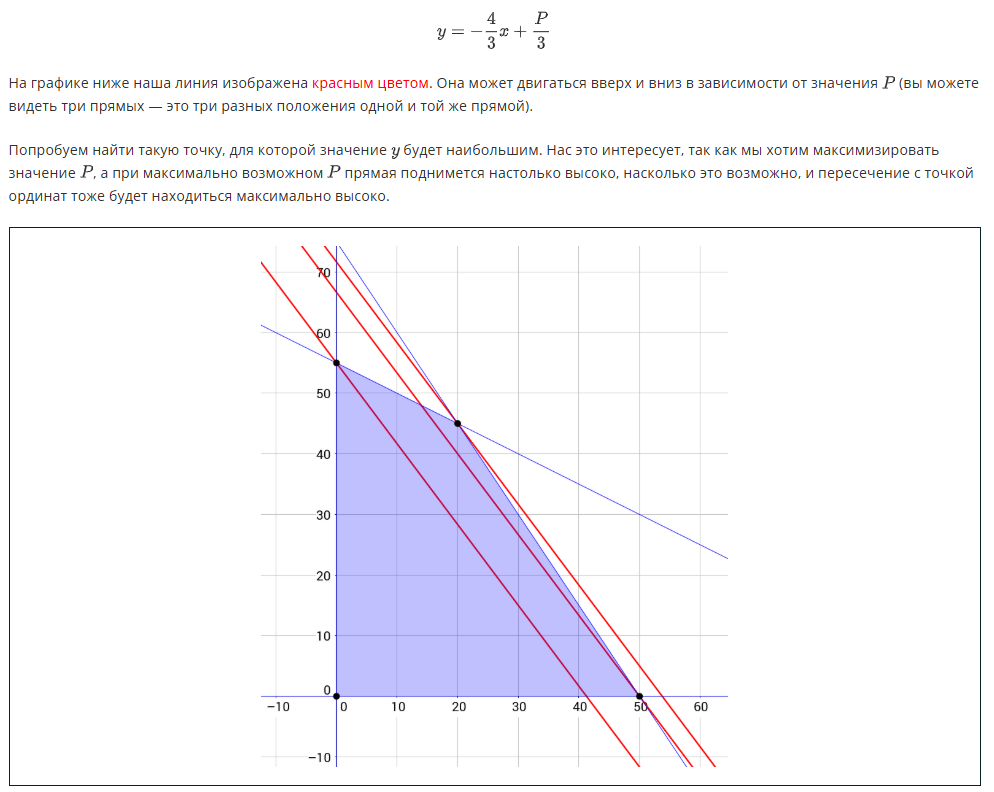

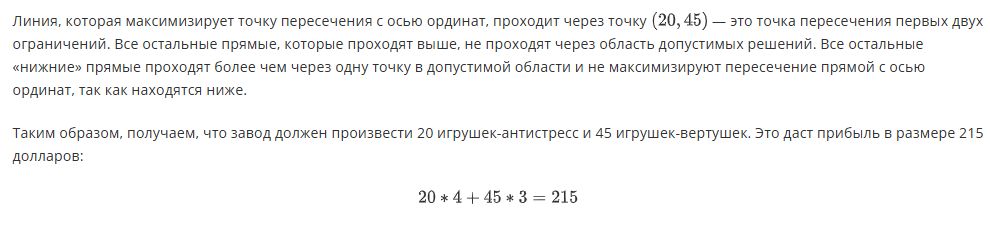

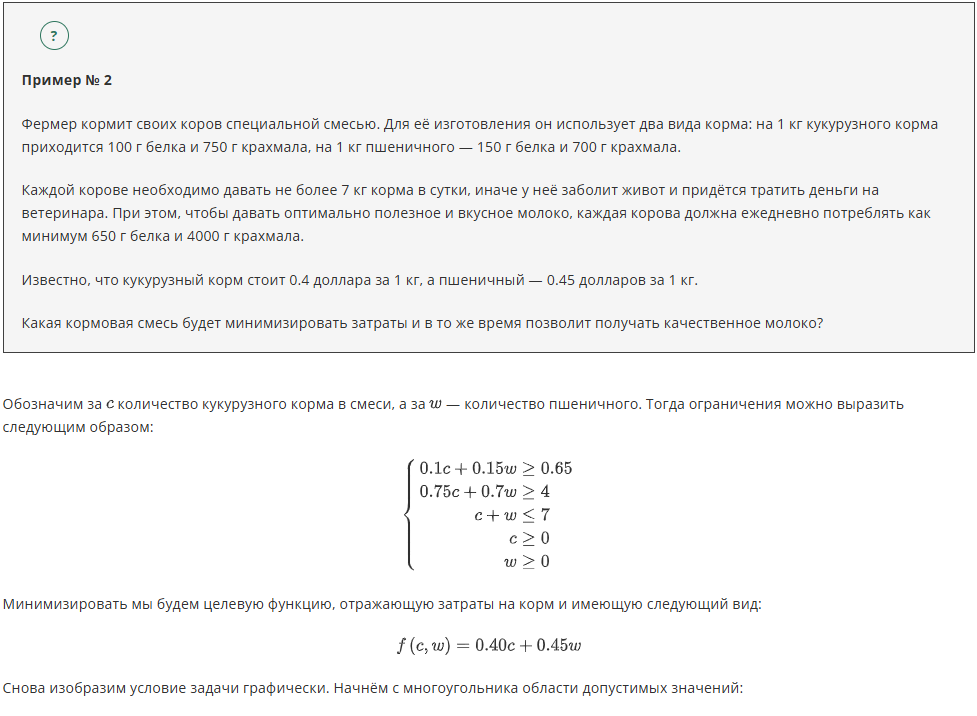

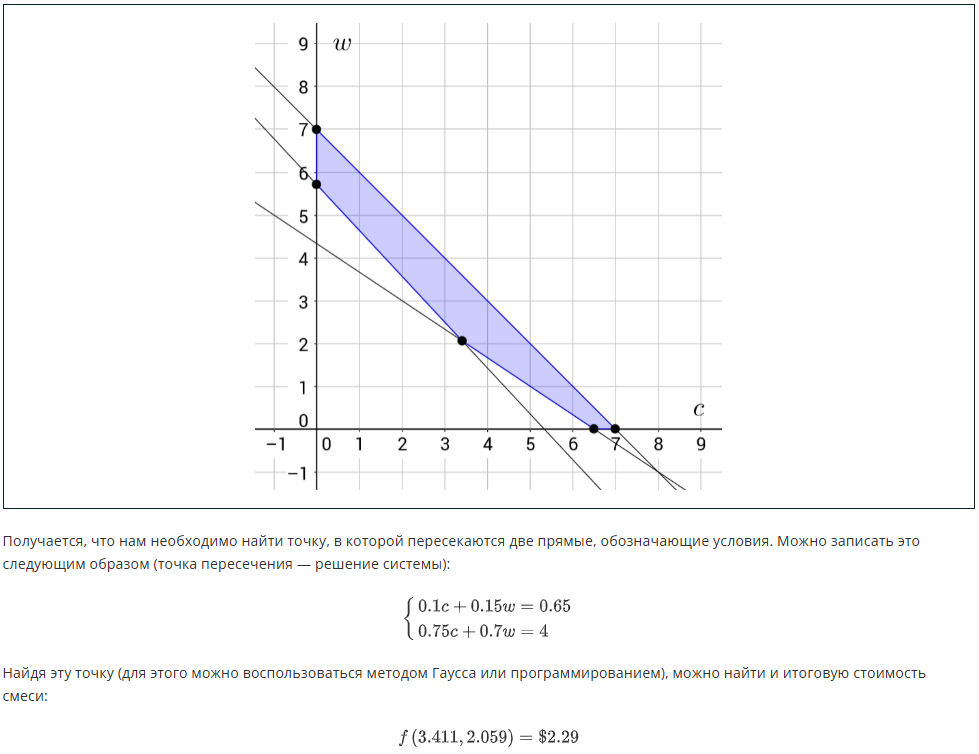

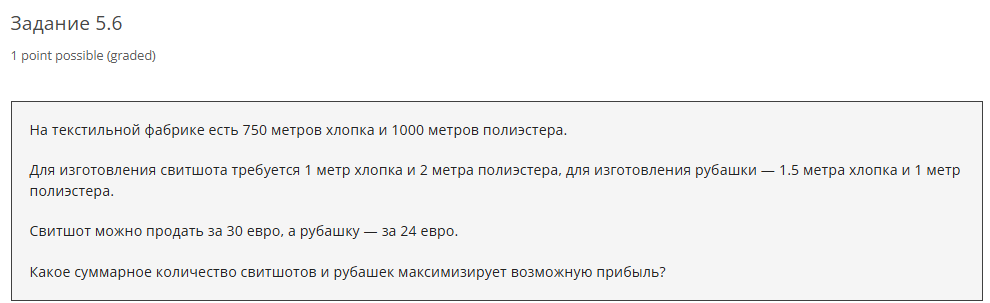

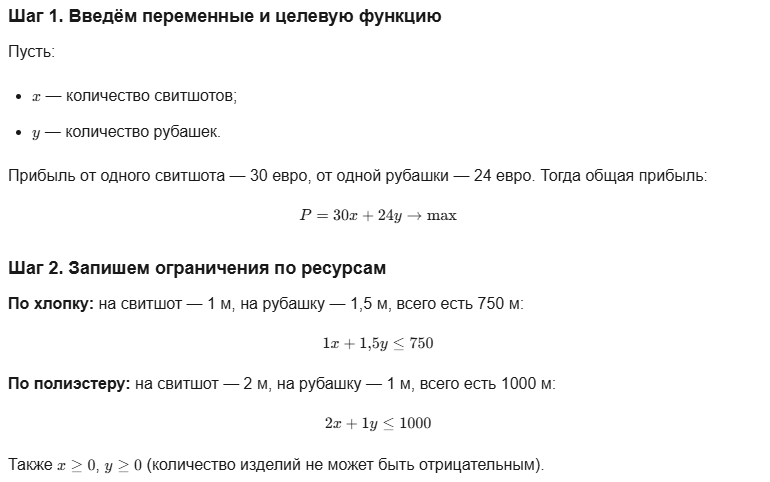

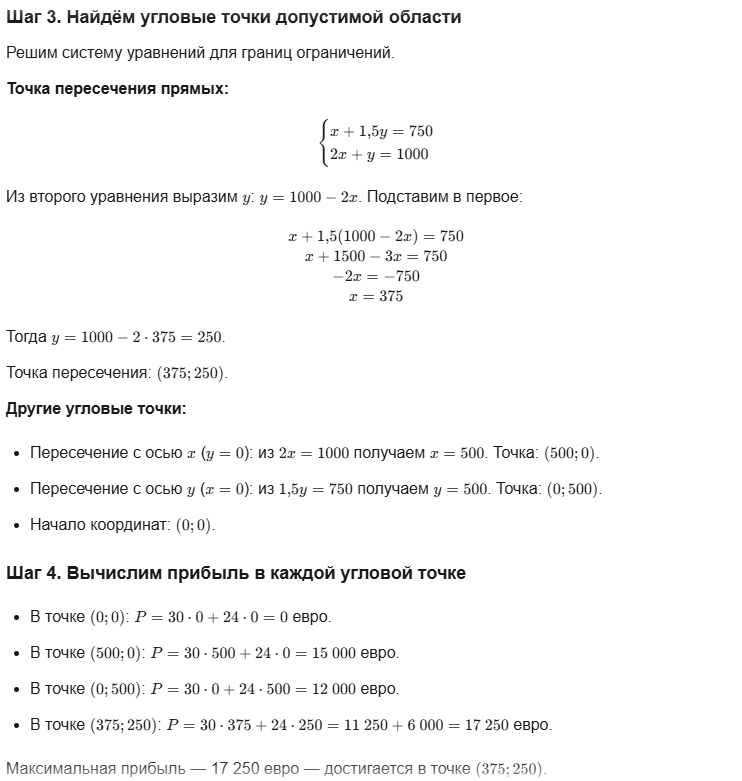

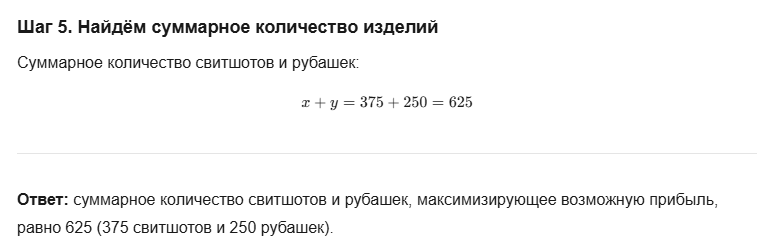

---

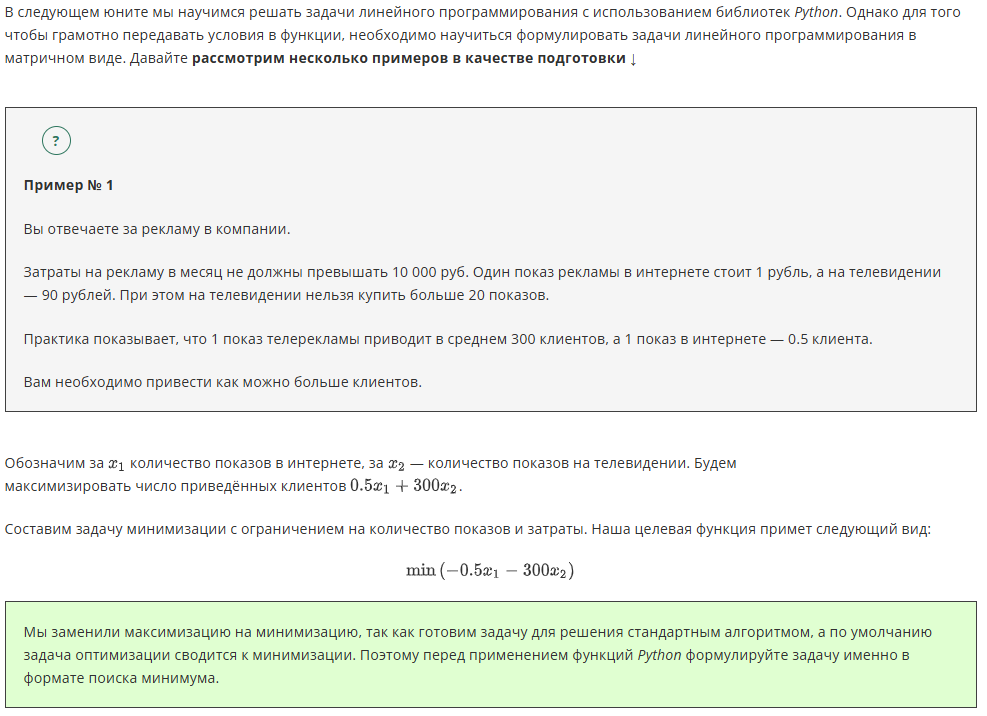

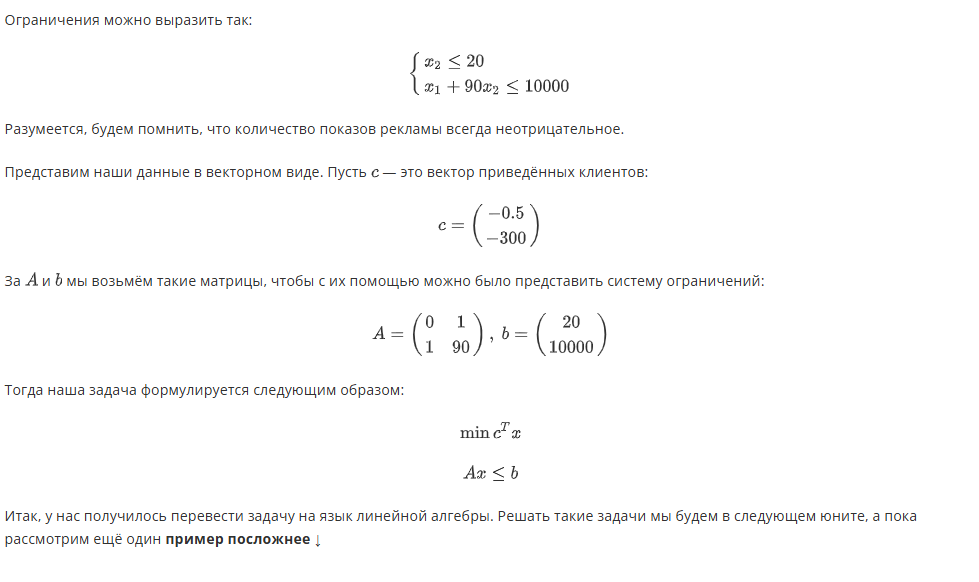

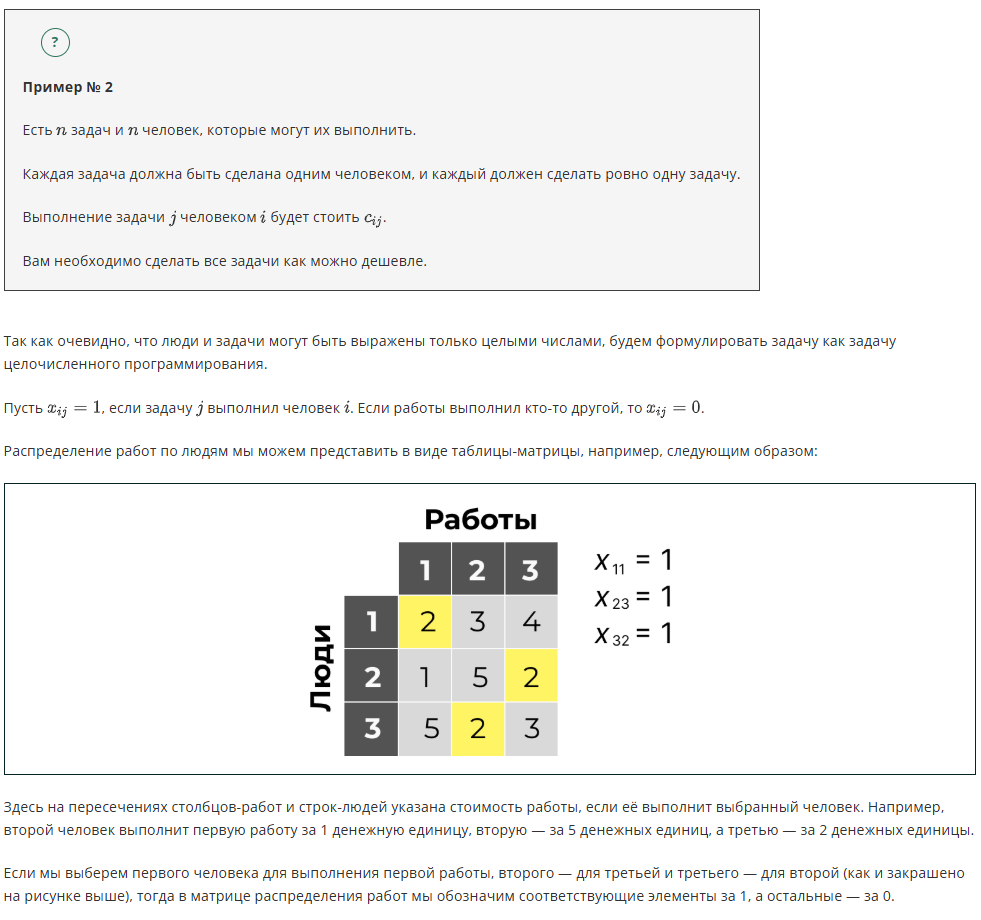

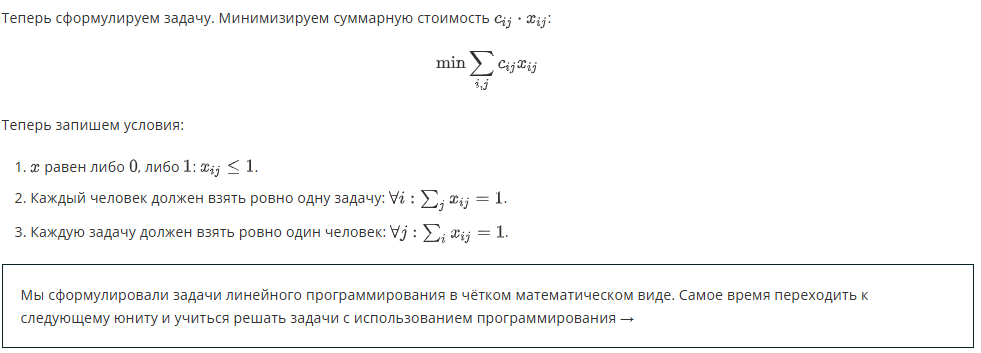

>**Дополнительно**

Если вам интересно изучить более сложные, но очень известные задачи оптимизации, к которым применимо линейное программирование, рекомендуем прочитать следующие статьи:
* [Задача коммивояжёра](https://habr.com/ru/articles/560468/)
* [Транспортная задача](https://habr.com/ru/articles/573224/)

---

# Практика: линейное программирование

В языке Python есть множество библиотек, с помощью которых можно решить задачу линейного программирования. Вот основные, которые мы рассмотрим в данном юните:
* **SciPy** (```scipy.optimize.linprog```);
* **CVXPY**; 
* **PuLP**.

У каждой библиотеки есть свои особенности использования, и большинство задач можно решить с помощью любой из них. Давайте посмотрим все варианты, чтобы у вас всегда был выбор — решим по одной задаче для каждой библиотеки.

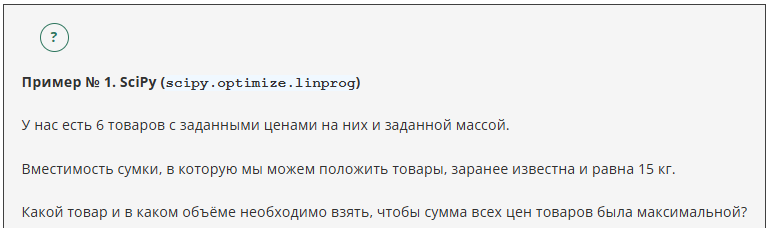

Создадим переменные на основе предложенных данных:

In [23]:
values = [4, 2, 1, 7, 3, 6] #стоимости товаров
weights = [5, 9, 8, 2, 6, 5] #вес товаров
C = 15 #вместимость сумки
n = 6 #количество товаров

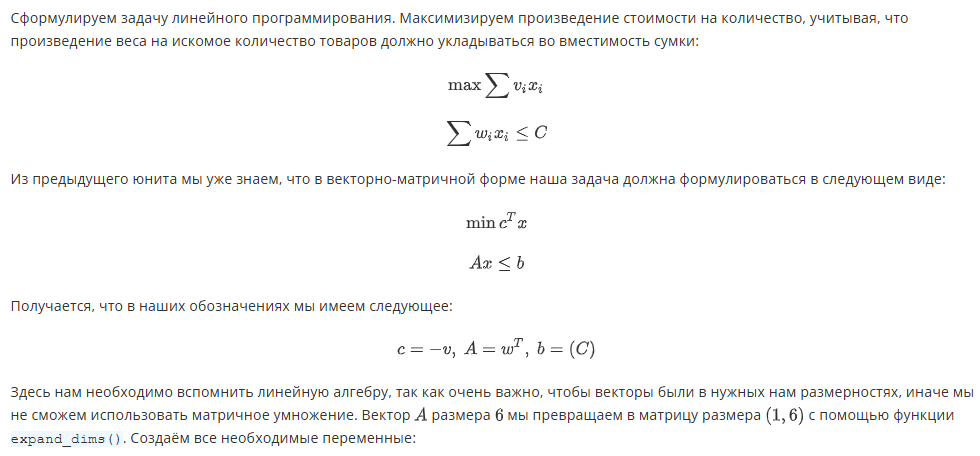

In [24]:
c = - np.array(values) #изменяем знак, чтобы перейти от задачи максимизации к задаче минимизации
A = np.array(weights)  #конвертируем список с весами в массив
A = np.expand_dims(A, 0) #преобразуем размерность массива
b = np.array([C]) #конвертируем вместимость в массив

Передаём подготовленные переменные в оптимизатор SciPy:

In [25]:
from scipy.optimize import linprog
linprog(c=c, A_ub=A, b_ub=b)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -52.5
              x: [ 0.000e+00  0.000e+00  0.000e+00  7.500e+00  0.000e+00
                   0.000e+00]
            nit: 0
          lower:  residual: [ 0.000e+00  0.000e+00  0.000e+00  7.500e+00
                              0.000e+00  0.000e+00]
                 marginals: [ 1.350e+01  2.950e+01  2.700e+01  0.000e+00
                              1.800e+01  1.150e+01]
          upper:  residual: [       inf        inf        inf        inf
                                    inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00]
                 marginals: [-3.500e+00]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

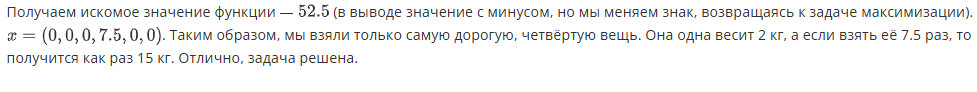

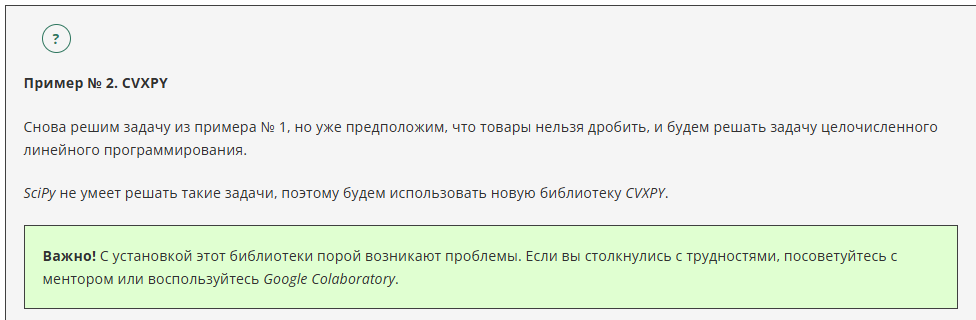

С помощью CVXPY создадим переменную-массив. Укажем его размерность, а также условие, что все числа в массиве должны быть целыми:

In [27]:
import cvxpy
x = cvxpy.Variable(shape=n, integer = True)

Далее зададим ограничения, используя матричное умножение:

In [28]:
A = A.flatten() # Преобразуем размерность массива
constraint = cvxpy.sum(cvxpy.multiply(A, x)) <= C
total_value = cvxpy.sum(cvxpy.multiply(x, c))

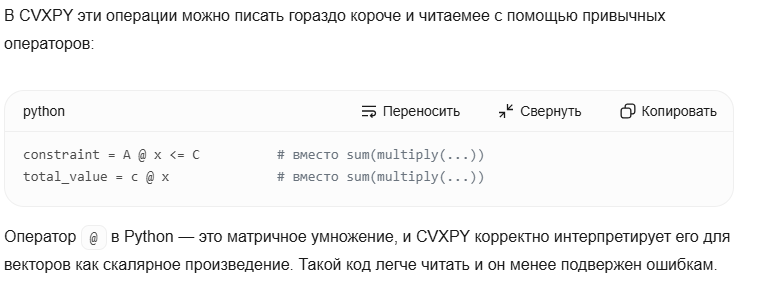

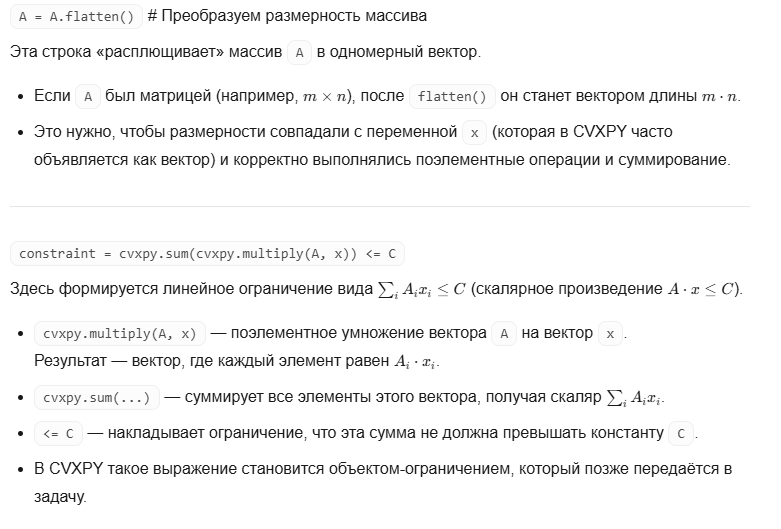

Переходим непосредственно к решению задачи:

In [29]:
problem = cvxpy.Problem(cvxpy.Minimize(total_value), constraints=[constraint])

In [30]:
problem.solve()

SolverError: Solver 'SCIPY' failed. Try another solver, or solve with verbose=True for more information.

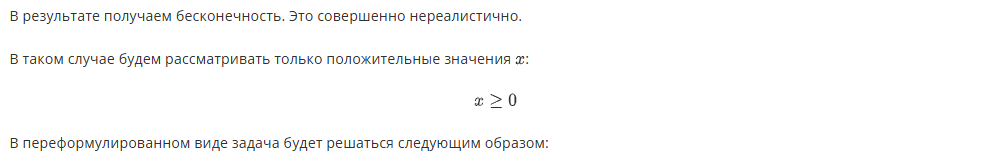

In [33]:
x = cvxpy.Variable(shape=n, integer=True)
constraint = cvxpy.sum(cvxpy.multiply(A, x)) <= C
x_positive = x >= 0
total_value = cvxpy.sum(cvxpy.multiply(x, c))

problem = cvxpy.Problem(
    cvxpy.Minimize(total_value), constraints=[constraint, x_positive]
)

problem.solve()


-49.0

In [34]:
x.value

array([-0., -0., -0.,  7., -0.,  0.])

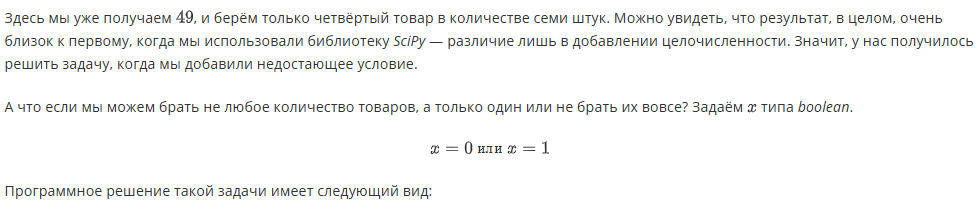

In [35]:
x = cvxpy.Variable(shape=n, boolean=True)
constraint = cvxpy.sum(cvxpy.multiply(A, x)) <= C
x_positive = x >= 0
total_value = cvxpy.sum(cvxpy.multiply(x, c))

problem = cvxpy.Problem(
    cvxpy.Minimize(total_value), constraints=[constraint, x_positive]
)

problem.solve()


-17.0

In [36]:
x.value

array([1., 0., 0., 1., 0., 1.])

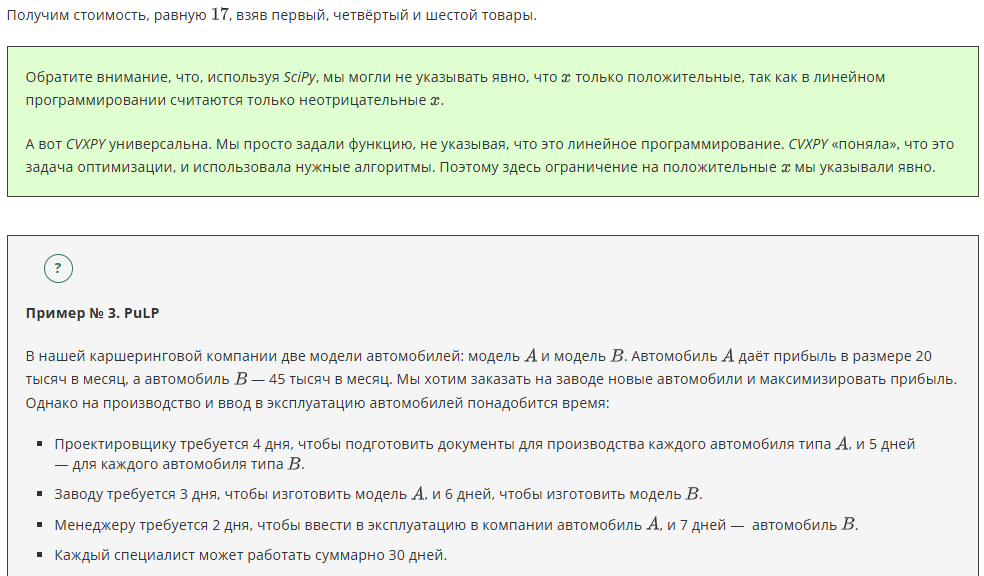

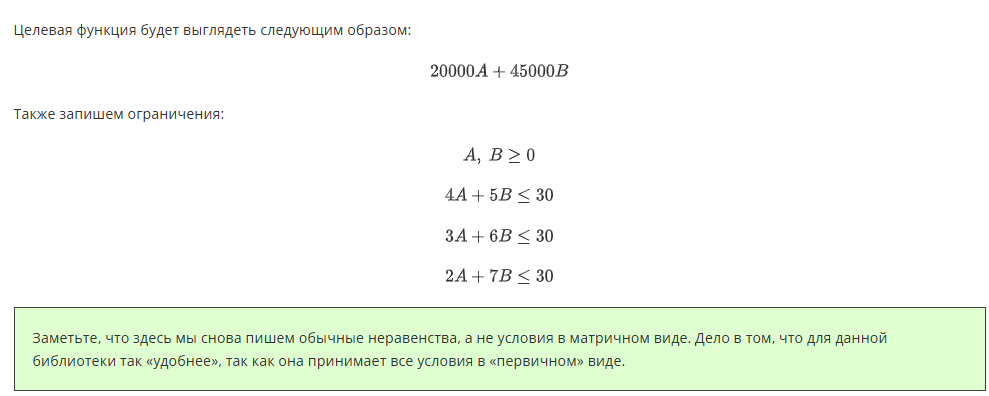

In [37]:
from pulp import *
problem = LpProblem('Производство машин', LpMaximize)
A = LpVariable('Автомобиль A', lowBound=0 , cat=LpInteger)
B = LpVariable('Автомобиль B', lowBound=0 , cat=LpInteger)
#Целевая функция
problem += 20000*A + 45000*B 
#Ограничения
problem += 4*A + 5*B <= 30 
problem += 3*A + 6*B <=30
problem += 2*A + 7*B <=30
problem.solve()
print("Количество автомобилей модели А: ", A.varValue)
print("Количество автомобилей модели В: ", B.varValue)
print("Суммарный доход: ", value(problem.objective))

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Количество автомобилей модели А:  1.0
Количество автомобилей модели В:  4.0
Суммарный доход:  200000.0


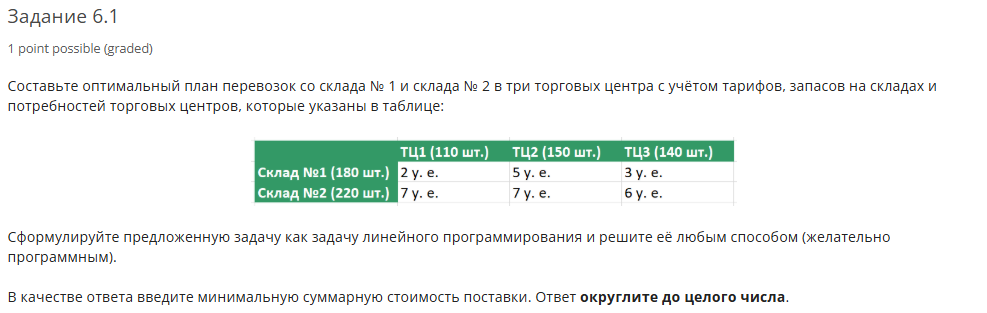

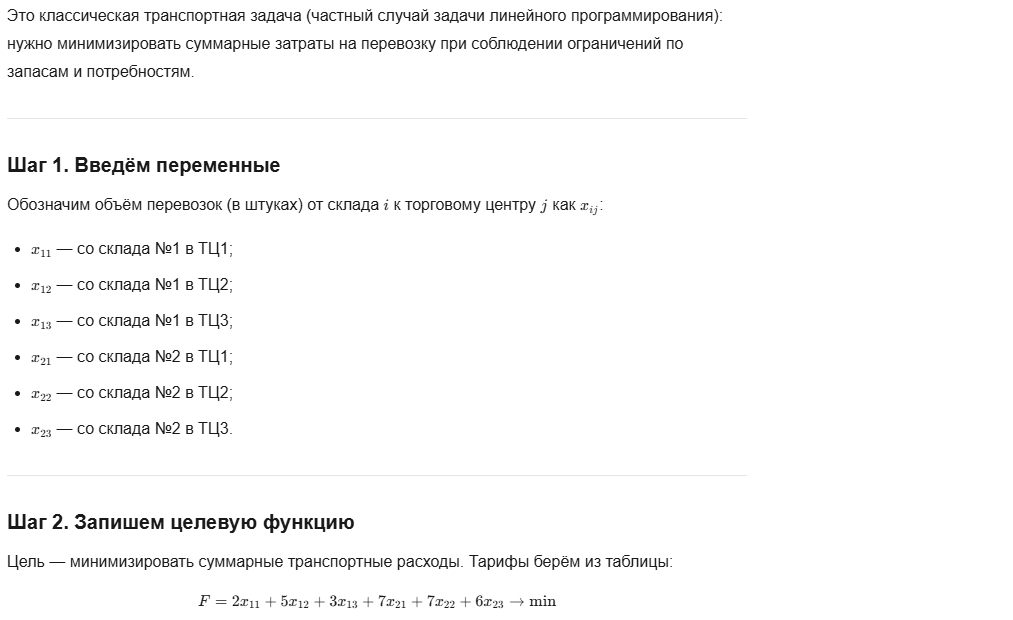

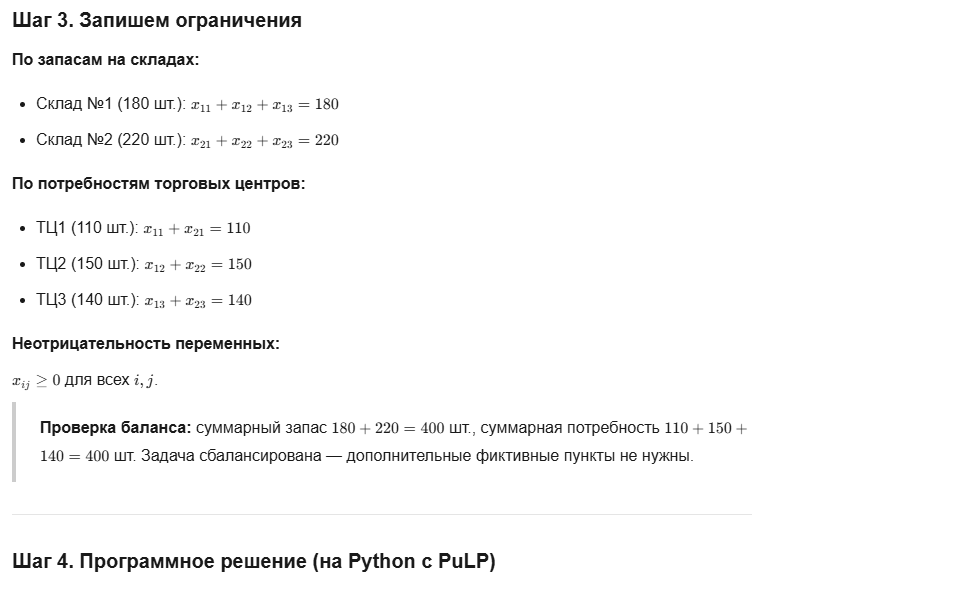

In [39]:
import pulp

# Создаём задачу на минимизацию
prob = pulp.LpProblem("Transport_Problem", pulp.LpMinimize)

# Индексы складов и ТЦ
warehouses = ['W1', 'W2']
stores = ['S1', 'S2', 'S3']

# Запасы и потребности
supply = {'W1': 180, 'W2': 220}
demand = {'S1': 110, 'S2': 150, 'S3': 140}

# Тарифы (у.е. за шт.)
costs = {
    ('W1', 'S1'): 2, ('W1', 'S2'): 5, ('W1', 'S3'): 3,
    ('W2', 'S1'): 7, ('W2', 'S2'): 7, ('W2', 'S3'): 6
}

# Переменные: x_ij >= 0
x = pulp.LpVariable.dicts("x", [(w, s) for w in warehouses for s in stores],
                          lowBound=0, cat='Continuous')

# Целевая функция: минимизация суммарных затрат
prob += pulp.lpSum(costs[(w, s)] * x[(w, s)] for w in warehouses for s in stores)

# Ограничения по запасам
for w in warehouses:
    prob += pulp.lpSum(x[(w, s)] for s in stores) == supply[w], f"Supply_{w}"

# Ограничения по потребностям
for s in stores:
    prob += pulp.lpSum(x[(w, s)] for w in warehouses) == demand[s], f"Demand_{s}"

# Решаем
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# Выводим результаты
print("Статус:", pulp.LpStatus[prob.status])
print("Оптимальные перевозки:")
for w in warehouses:
    for s in stores:
        val = x[(w, s)].varValue
        if val > 0:
            print(f"  {w} → {s}: {val:.0f} шт.")
print(f"Суммарные затраты: {pulp.value(prob.objective):.0f} у.е.")

Статус: Optimal
Оптимальные перевозки:
  W1 → S1: 110 шт.
  W1 → S3: 70 шт.
  W2 → S2: 150 шт.
  W2 → S3: 70 шт.
Суммарные затраты: 1900 у.е.


---

In [40]:
from scipy.optimize import linprog
import numpy as np

In [41]:
cost = np.array([
    [2, 5, 3],
    [7, 7, 6]
])
stock = np.array([180, 220])
demand = np.array([110, 150, 140])
num_warehouse = 2
num_clients = 3

$x_{ij}$ - сколько забирается со i склада клиенту j  
$$f = \sum_{i,j} cost_{ij} * x_{ij}$$

In [42]:
c = cost.flatten()
print(c) 

[2 5 3 7 7 6]


Для каждого склада количество взятых предметов должно быть меньше, чем на складе:

$$\forall i: \sum_j x_{ij} \leq stock_i$$

In [43]:
A = []
b = []
for i in range(0, num_warehouse):
    A.append([0] * (num_clients * i) + [1] * num_clients + [0] * (num_clients * (num_warehouse - i - 1)))
    b.append(stock[i])
A = np.asarray(A)
b = np.asarray(b)
print(A)
print(b)

[[1 1 1 0 0 0]
 [0 0 0 1 1 1]]
[180 220]


Для каждого клиента количество приобретаемых товаров должно быть больше на единицу, чем спрос:

$$\forall j: \sum_i x_{ij} \geq demand_j$$

Который также:

$$\forall j: - \sum_i x_{ij} \leq -demand_j$$

In [44]:
A = A.tolist()
b = b.tolist()
for j in range(0, num_clients):
    A.append(([0] * j + [-1] + [0] * (num_clients - j - 1)) * num_warehouse)
    b.append(-demand[j])
A = np.asarray(A)
b = np.asarray(b)
print(A)
print(b)

[[ 1  1  1  0  0  0]
 [ 0  0  0  1  1  1]
 [-1  0  0 -1  0  0]
 [ 0 -1  0  0 -1  0]
 [ 0  0 -1  0  0 -1]]
[ 180  220 -110 -150 -140]


In [45]:
linprog(c=c, A_ub=A, b_ub=b)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 1900.0
              x: [ 1.100e+02  0.000e+00  7.000e+01  0.000e+00  1.500e+02
                   7.000e+01]
            nit: 5
          lower:  residual: [ 1.100e+02  0.000e+00  7.000e+01  0.000e+00
                              1.500e+02  7.000e+01]
                 marginals: [ 0.000e+00  1.000e+00  0.000e+00  2.000e+00
                              0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf        inf        inf
                                    inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00]
                 marginals: [-3.000e+00 -0.000e+00 -5.00

---

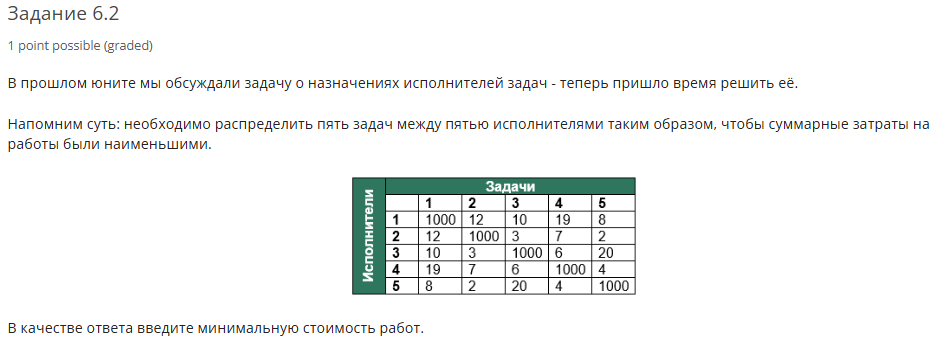

In [46]:
import pulp

# Создаём задачу на минимизацию
prob = pulp.LpProblem("Assignment_Problem", pulp.LpMinimize)

# Индексы исполнителей и задач (от 1 до 5)
workers = range(1, 6)
tasks = range(1, 6)

# Матрица затрат (строки — исполнители, столбцы — задачи)
costs = [
    [1000, 12, 10, 19, 8],
    [12, 1000, 3, 7, 2],
    [10, 3, 1000, 6, 20],
    [19, 7, 6, 1000, 4],
    [8, 2, 20, 4, 1000]
]

# Переменные: x[i][j] = 1, если исполнитель i выполняет задачу j, иначе 0
x = {}
for i in workers:
    for j in tasks:
        x[i, j] = pulp.LpVariable(f"x_{i}_{j}", lowBound=0, upBound=1, cat="Binary")

# Целевая функция: минимизация суммарных затрат
prob += pulp.lpSum(costs[i-1][j-1] * x[i, j] for i in workers for j in tasks)

# Ограничения: каждый исполнитель выполняет ровно одну задачу
for i in workers:
    prob += pulp.lpSum(x[i, j] for j in tasks) == 1, f"OneTaskPerWorker_{i}"

# Ограничения: каждая задача выполняется ровно одним исполнителем
for j in tasks:
    prob += pulp.lpSum(x[i, j] for i in workers) == 1, f"OneWorkerPerTask_{j}"

# Решаем задачу
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# Выводим результаты
print("Статус:", pulp.LpStatus[prob.status])
print("Оптимальные назначения:")
total_cost = 0
for i in workers:
    for j in tasks:
        if x[i, j].varValue > 0.5:
            print(f"Исполнитель {i} → Задача {j} (стоимость {costs[i-1][j-1]})")
            total_cost += costs[i-1][j-1]
print(f"Минимальная суммарная стоимость: {total_cost}")

Статус: Optimal
Оптимальные назначения:
Исполнитель 1 → Задача 5 (стоимость 8)
Исполнитель 2 → Задача 3 (стоимость 3)
Исполнитель 3 → Задача 4 (стоимость 6)
Исполнитель 4 → Задача 2 (стоимость 7)
Исполнитель 5 → Задача 1 (стоимость 8)
Минимальная суммарная стоимость: 32


---

In [47]:
from scipy.optimize import linprog
import numpy as np
import cvxpy as cvx

#### Матрица стоимостей $C$

In [ ]:
c = np.array([
    [1000, 12, 10, 19, 8],
    [12, 1000, 3, 7, 2], 
    [10, 3, 1000, 6, 20], 
    [19, 7, 6, 1000, 4], 
    [8, 2, 20, 4, 1000]])



#### Матрица переменных $X$

In [49]:
x = cvx.Variable(shape=(5,5), boolean=True)

#### Ограничения (сумма $X$ по строкам и столбцам равна 1)

In [50]:
constraints = [
    cvx.sum(x, axis=0) == np.ones(5),
    cvx.sum(x, axis=1) == np.ones(5)
]
    

#### Целевая функция (сумма $CX$)

In [52]:
func = cvx.sum(cvx.multiply(x, c))
problem = cvx.Problem(cvx.Minimize(func), constraints=constraints)
problem.solve()

32.0

In [53]:
np.round(x.value)

array([[ 0.,  0., -0.,  0.,  1.],
       [ 0.,  0.,  1.,  0.,  0.],
       [ 1., -0.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0., -0.],
       [-0.,  0.,  0.,  1.,  0.]])

---

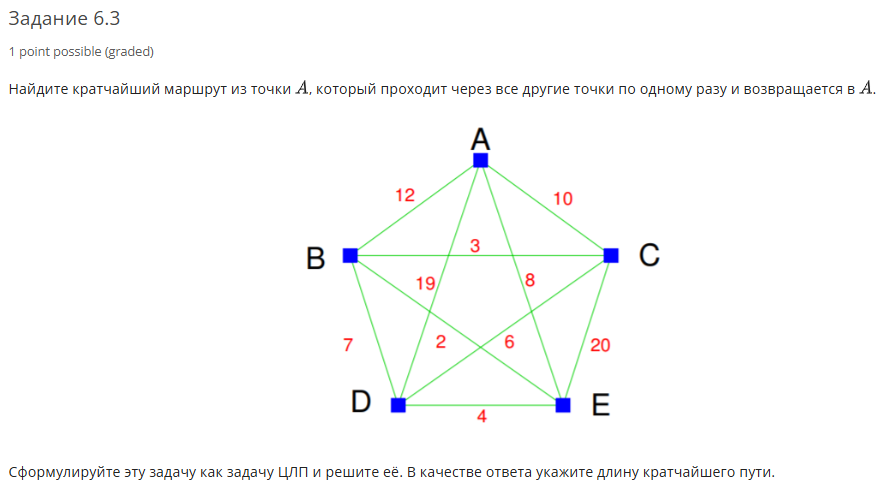

In [62]:
import cvxpy as cvx
import numpy as np

Пусть X будет массивом булевых значений 5x5. Если X[A, B] = True, то маршрут проходит по ребру (A, B).

In [63]:
x = cvx.Variable(shape=(5, 5), boolean=True)

Пусть C будет массивом целочисленных значений, в котором хранятся расстояния между вершинами.

In [64]:
c = np.array(
    [
        [0, 12, 10, 19, 8],
        [12, 0, 3, 7, 2],
        [10, 3, 0, 6, 20],
        [19, 7, 6, 0, 4],
        [8, 2, 20, 4, 0],
    ]
)

Зададим ограничения. Нетрудно заметить, что кратчайший маршрут будет соединять ровно 5 пар точек – то есть, сумма x по обеим осям будет равна 5.

In [65]:
constraints = [
    cvx.sum(x, axis=0) == np.ones(5),
    cvx.sum(x, axis=1) == np.ones(5),
]

Также заметим, что "нулевое ребро" между каждой точкой и ней самой же не может входить в наш маршрут – то есть, на главной диагонали X располагаются нули.

In [66]:
for i in range(5):
    constraints.append(x[i, i] == 0)

Для исключения коротких циклов A-B-A, из-за которых решение становится несвязным, введём ограничение: путь между двумя точками может быть пройден не более одного раза.

In [67]:
for i in range(4):
    for j in range(i + 1, 5):
        constraints.append(x[i, j] + x[j, i] <= 1)

Определим функцию, считающую длину маршрута.

In [68]:
func = cvx.sum(cvx.multiply(x, c))

In [69]:
problem = cvx.Problem(cvx.Minimize(func), constraints=constraints)

In [70]:
problem.solve()

32.0

### Найденный путь
Посмотрим на найденный наикратчайший путь. Для этого взглянем на значения матрицы X, при которых достигается минимальная длина пути.

In [71]:
np.round(x.value)

array([[ 0.,  0., -0.,  0.,  1.],
       [-0.,  0.,  1., -0., -0.],
       [ 1., -0.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [-0.,  0.,  0.,  1.,  0.]])

Это означает, что вершина A - первая в маршруте, B - третья, C - вторая, D - четвёртая. Эту же информацию можно достать из матрицы $X$.  
Искомое решение.

![alt text](https://i.ibb.co/qJzt4LW/image.png)

Обратите внимание, что в заданиях 6.2 и 6.3 для записи двух разных задач используется почти одна и та же система уравнений!

---

# Дополнительные методы оптимизации. Практика

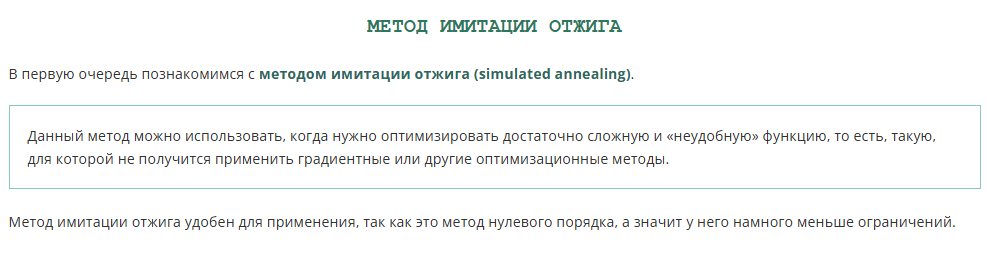

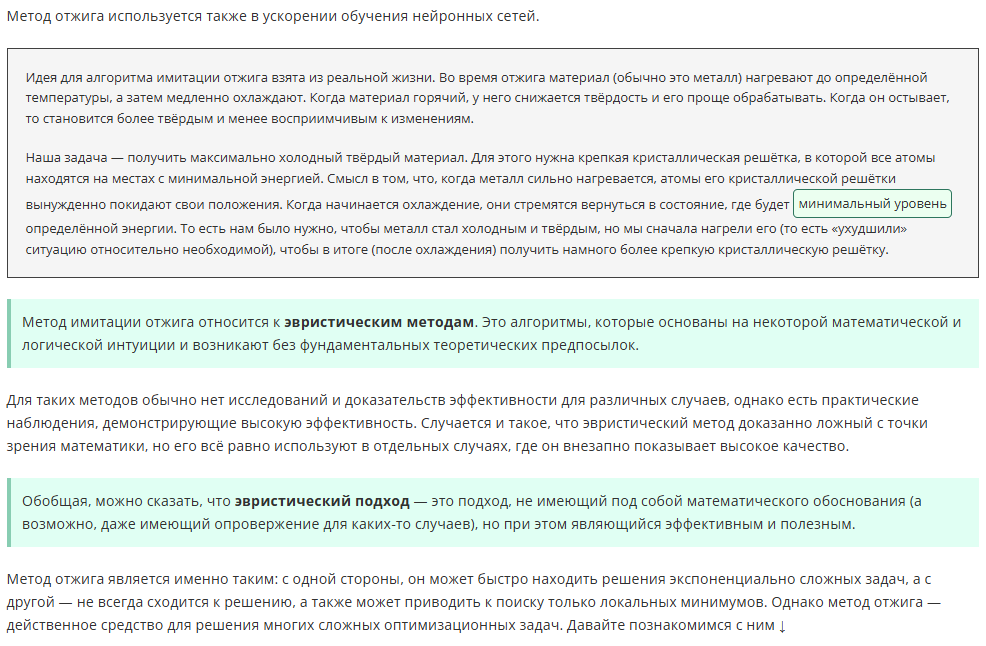

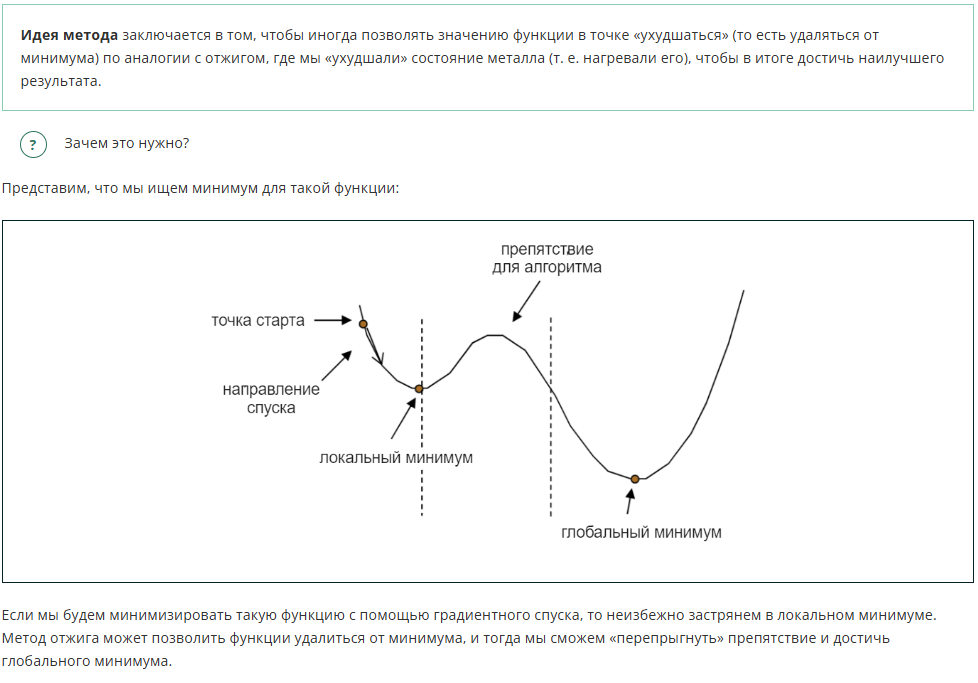

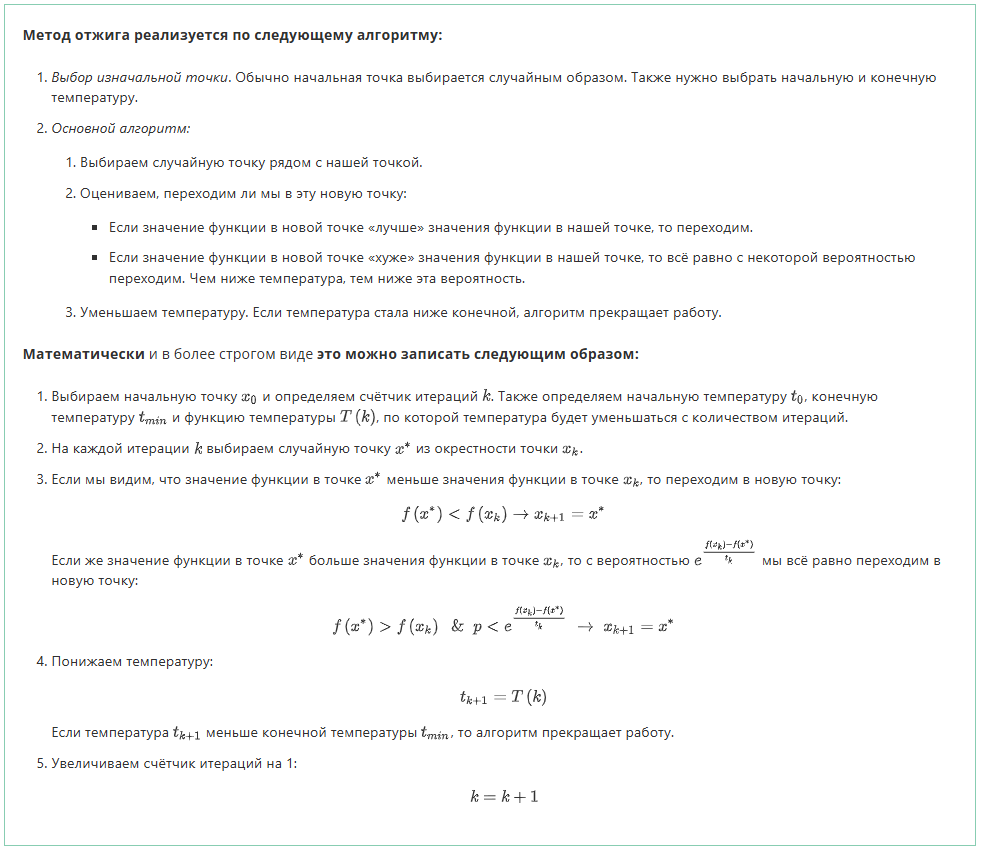

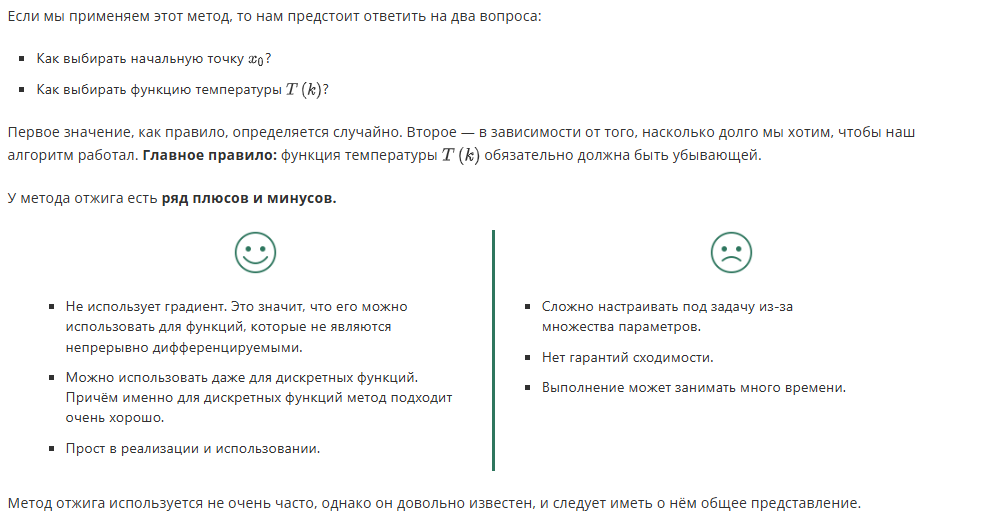

Если вам интересно подробнее узнать про метод отжига и посмотреть на его имплементацию в Python, рекомендуем ознакомиться со следующей [статьёй](https://dev.to/cesarwbr/how-to-implement-simulated-annealing-algorithm-in-python-4gid).

---

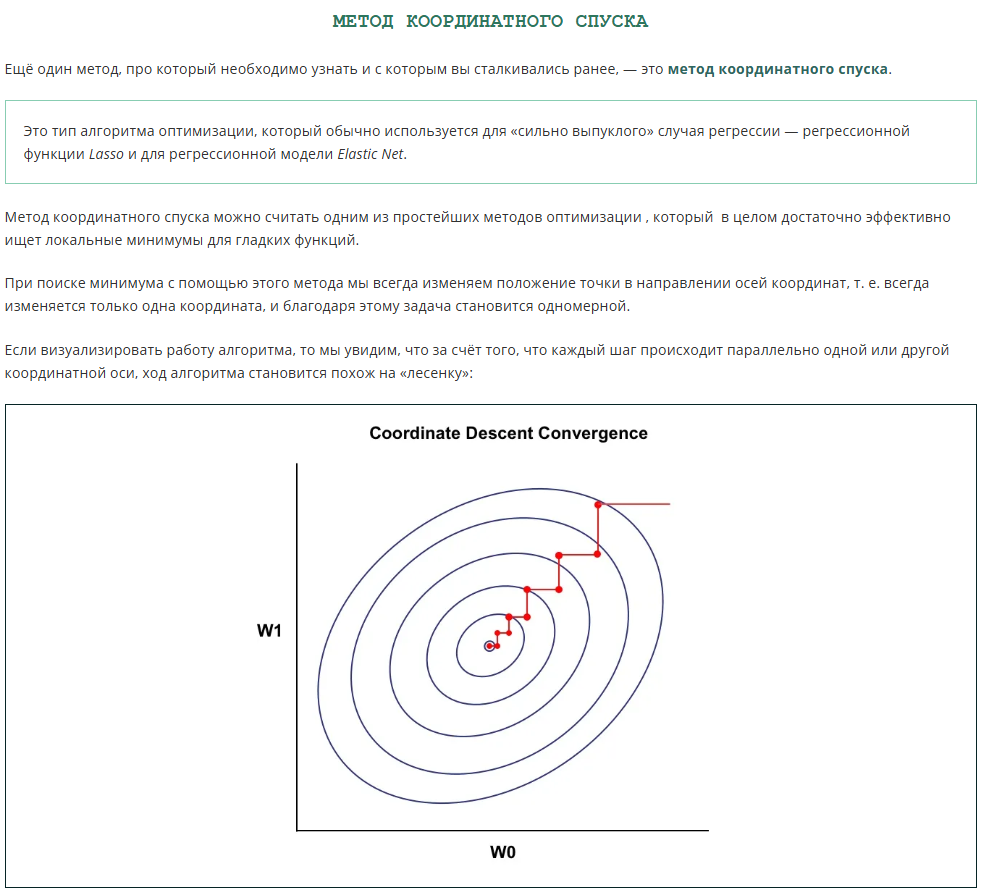

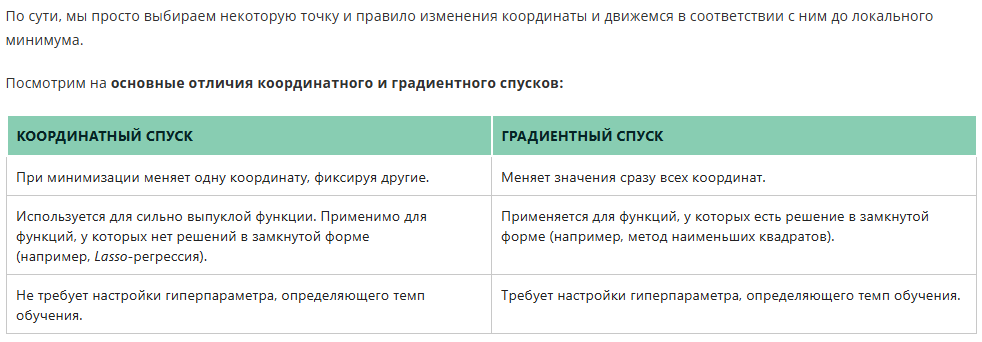

---